# 0. Setup

In [3]:
# reload all modules every time before executing
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from pathlib import Path
import sys, types

import numpy as np

In [5]:
# Patch for pickle compatibility
if 'recover_core_lib' not in sys.modules:
    print('adding `recover_core_lib` to sys')
    fake = types.ModuleType('recover_core_lib')
    fake.compute_CAM2_translations_v3_cupy = lambda *a, **k: None
    sys.modules['recover_core_lib'] = fake

adding `recover_core_lib` to sys


In [6]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [7]:
# this automatically displays all plots, even if we don't have plt.show()
# this also makes all plots interactive
%matplotlib widget

# 1. Load Data

In [8]:
import json
from collections import defaultdict

In [9]:
BASE_DIR = Path('../data/experiment-02/')
exp_dirs = sorted([d for d in BASE_DIR.iterdir() if d.is_dir() and '.ipynb' not in str(d)])
print(f'Found {len(exp_dirs)} experiment directories')
exp_dirs

Found 74 experiment directories


[PosixPath('../data/experiment-02/cube-00x-00y--18-01-15-54-19'),
 PosixPath('../data/experiment-02/cube-00x-00y--18-01-15-56-07'),
 PosixPath('../data/experiment-02/cube-00x-01y--18-01-15-57-49'),
 PosixPath('../data/experiment-02/cube-00x-02y--18-01-15-58-34'),
 PosixPath('../data/experiment-02/cube-00x-03y--18-01-15-59-15'),
 PosixPath('../data/experiment-02/cube-00x-04y--18-01-15-59-54'),
 PosixPath('../data/experiment-02/cube-00x-05y--18-01-16-00-37'),
 PosixPath('../data/experiment-02/cube-00x-06y--18-01-16-01-15'),
 PosixPath('../data/experiment-02/cube-00x-06y--18-01-16-02-04'),
 PosixPath('../data/experiment-02/cube-01x-01y--18-01-16-02-55'),
 PosixPath('../data/experiment-02/cube-01x-02y--18-01-16-04-17'),
 PosixPath('../data/experiment-02/cube-01x-03y--18-01-16-05-28'),
 PosixPath('../data/experiment-02/cube-01x-04y--18-01-16-14-56'),
 PosixPath('../data/experiment-02/cube-01x-05y--18-01-16-17-35'),
 PosixPath('../data/experiment-02/cube-01x-06y--18-01-16-18-59'),
 PosixPath

In [10]:
def load_data(exp_dirs, grid_width=7) -> dict:
    """Load recovery and metadata from an experiment directory.

    Args:
        exp_dirs: list of experiment directory paths
        grid_width: width of the 2D grid for computing linearized position index

    Returns:
        dict of experiment data with position_xy (tuple) and position_idx (int) fields
    """

    duplicate_idx_map = defaultdict(int)
    data = {}

    for exp_dir in exp_dirs:
        with open(exp_dir / "experiment_config.json", "r") as f: config = json.load(f)
        fs = config["FPS"]

        object = str(exp_dir).split('/')[-1].split('-')[0]
        x_position = None if object == 'empty' else int(str(exp_dir).split('/')[-1].split('-')[1][:2])
        y_position = None if object == 'empty' else int(str(exp_dir).split('/')[-1].split('-')[2][:2])

        key = (object, x_position, y_position)
        duplicate_idx_map[key] += 1
        duplicate_idx = duplicate_idx_map[key]

        name = f'{object}-{x_position}x-{y_position}y-{duplicate_idx:02}'

        recovery = np.load(exp_dir / 'RECOVERY.npz', allow_pickle=True)
        shifts_raw = recovery['all_shifts']
        time = np.arange(shifts_raw.shape[1]) / fs

        # Compute 2D position tuple and linearized index for classification
        position_xy = (x_position, y_position) if x_position is not None else None
        position_idx = (y_position * grid_width + x_position) if x_position is not None else None

        d = {
            'object': object,
            'x_position': x_position,
            'y_position': y_position,
            'position_xy': position_xy,  # tuple (x, y) for display/grouping
            'position_idx': position_idx,  # linearized index for classification
            'duplicate_idx': duplicate_idx,
            'fs': fs,
            'path': exp_dir,
            'shifts_raw': shifts_raw,
            'time': time,
        }
        data[name] = d
    return data

In [11]:
data = load_data(exp_dirs)
len(data)

74

In [12]:
list(data.keys())

['cube-0x-0y-01',
 'cube-0x-0y-02',
 'cube-0x-1y-01',
 'cube-0x-2y-01',
 'cube-0x-3y-01',
 'cube-0x-4y-01',
 'cube-0x-5y-01',
 'cube-0x-6y-01',
 'cube-0x-6y-02',
 'cube-1x-1y-01',
 'cube-1x-2y-01',
 'cube-1x-3y-01',
 'cube-1x-4y-01',
 'cube-1x-5y-01',
 'cube-1x-6y-01',
 'cube-2x-0y-01',
 'cube-2x-1y-01',
 'cube-2x-1y-02',
 'cube-2x-2y-01',
 'cube-2x-3y-01',
 'cube-2x-4y-01',
 'cube-2x-5y-01',
 'cube-2x-6y-01',
 'cube-3x-0y-01',
 'cube-3x-1y-01',
 'cube-3x-2y-01',
 'cube-3x-3y-01',
 'cube-3x-4y-01',
 'cube-3x-5y-01',
 'cube-3x-6y-01',
 'cube-4x-0y-01',
 'cube-4x-1y-01',
 'cube-4x-2y-01',
 'cube-4x-2y-02',
 'cube-4x-3y-01',
 'cube-4x-4y-01',
 'cube-4x-5y-01',
 'cube-4x-6y-01',
 'cube-5x-0y-01',
 'cube-5x-1y-01',
 'cube-5x-2y-01',
 'cube-5x-3y-01',
 'cube-5x-4y-01',
 'cube-5x-5y-01',
 'cube-5x-6y-01',
 'cube-6x-0y-01',
 'cube-6x-1y-01',
 'cube-6x-2y-01',
 'cube-6x-3y-01',
 'cube-6x-4y-01',
 'cube-6x-5y-01',
 'cube-6x-6y-01',
 'cube-7x-0y-01',
 'cube-7x-1y-01',
 'cube-7x-2y-01',
 'cube-7x-

In [13]:
list(list(data.values())[0].keys())

['object',
 'x_position',
 'y_position',
 'position_xy',
 'position_idx',
 'duplicate_idx',
 'fs',
 'path',
 'shifts_raw',
 'time']

In [14]:
list(data.values())[0]['shifts_raw'].shape, list(data.values())[0]['shifts_raw'].dtype

((100, 9000, 2), dtype('float32'))

# 2. Compute FFT

In [15]:
def shifts_to_fft(shifts, fs, min_freq=None, max_freq=None):
    # compute fft values and frequencies
    fft_val = np.fft.rfft(shifts, axis=1)
    n_samples = shifts.shape[1]
    freq = np.fft.rfftfreq(n_samples, d=1.0/fs)

    # crop the frequency
    if min_freq is not None and max_freq is not None:
        mask = (freq >= min_freq) & (freq <= max_freq)
        fft_val, freq = fft_val[:, mask, :], freq[mask]
    return fft_val, freq

In [16]:
def fft_magnitude(fft_vals, return_std=False):
    """Compute fft magnitude and average it over all the lasers and x,y coordinates"""
    if len(fft_vals.shape) == 3: # (n_lasers, n_freqs, n_coords)
        fft_mag_mean = np.abs(fft_vals).mean(axis=(0,2))
        return (fft_mag_mean, np.abs(fft_vals).std(axis=(0,2))) if return_std else fft_mag_mean
    elif len(fft_vals.shape) == 2: # (n_lasers, n_coords) we already chose a specific frequency
        fft_mag_mean = np.abs(fft_vals).mean()
        return (fft_mag_mean, np.abs(fft_vals).std()) if return_std else fft_mag_mean
    else:
        raise ValueError()

In [17]:
def fft_angle(fft_vals, return_std=False):
    """Compute fft angle and average it over all the lasers and x,y coordinates"""
    if len(fft_vals.shape) == 3: # (n_lasers, n_freqs, n_coords)
        fft_mag_mean = np.angle(fft_vals).mean(axis=(0,2))
        return (fft_mag_mean, np.angle(fft_vals).std(axis=(0,2))) if return_std else fft_mag_mean
    elif len(fft_vals.shape) == 2: # (n_lasers, n_coords) we already chose a specific frequency
        fft_mag_mean = np.angle(fft_vals).mean()
        return (fft_mag_mean, np.angle(fft_vals).std()) if return_std else fft_mag_mean
    else:
        raise ValueError()

# 3. Clean Data

In [18]:
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

In [19]:
def bandpass_filter(shifts, fs, lowcut=50, highcut=None, order=5):
    """Removes frequencies outside of [lowcut, highcut].
    sosfiltfilt applies the filter forward and backward, giving zero phase distortion."""
    if highcut is None: highcut = fs / 2 - 10  # Slightly below Nyquist frequency

    n_lasers, _, n_coords = shifts.shape
    filtered_shifts = np.empty_like(shifts)

    for i in range(n_lasers):
        for j in range(n_coords):
            sos = butter(order, [lowcut, highcut], fs=fs, btype='band', output='sos')
            filtered_shifts[i, :, j] = sosfiltfilt(sos, shifts[i, :, j])
    return filtered_shifts

In [20]:
def hann_window(shifts):
    window = np.hanning(shifts.shape[1])
    return shifts * window[:, np.newaxis]

In [21]:
def plot_clean_data(shifts, fs, xlim=(None, None)):
    # fft for raw signal
    fft_vals, freq = shifts_to_fft(shifts, fs)

    # fft for bandpass filter
    bp_shifts = bandpass_filter(shifts, fs)
    bp_fft_vals, bp_freq = shifts_to_fft(bp_shifts, fs)

    # fft for bandpass filter + hann window
    wd_shifts = hann_window(bp_shifts)
    wd_fft_vals, wd_freq = shifts_to_fft(wd_shifts, fs)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(freq, fft_magnitude(fft_vals), label='raw')
    ax.plot(bp_freq, fft_magnitude(bp_fft_vals), label='bandpass filter')
    ax.plot(wd_freq, fft_magnitude(wd_fft_vals), label='bandpass filter + hann window')
    ax.set(xlim=xlim, ylim=(0, 200), xlabel='Frequency (Hz)', ylabel='Mean FFT Magnitude')
    ax.legend()
    fig.suptitle('Clean the Data')
    return fig

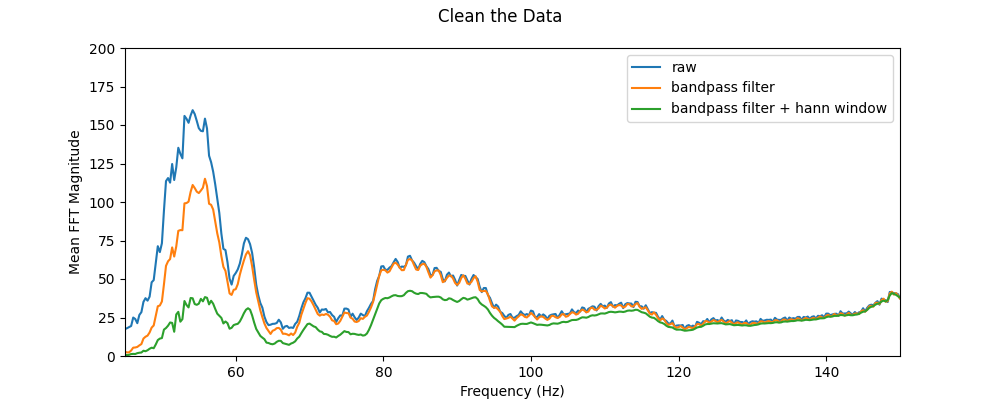

In [22]:
d = list(data.values())[0]
fig = plot_clean_data(d['shifts_raw'], d['fs'], xlim=(45, 150))
plt.show()

In [23]:
plt.close(fig)

The fft vals looks much cleaner with bandpass filter + hann window. Let's define a function to clean the shifts and compute the fft on this cleaned data.

In [24]:
def clean_shifts(shifts, fs):
    shifts_bp = bandpass_filter(shifts, fs)
    shifts_wd = hann_window(shifts_bp)
    return shifts_wd

Now let's take a look at all the frequencies.

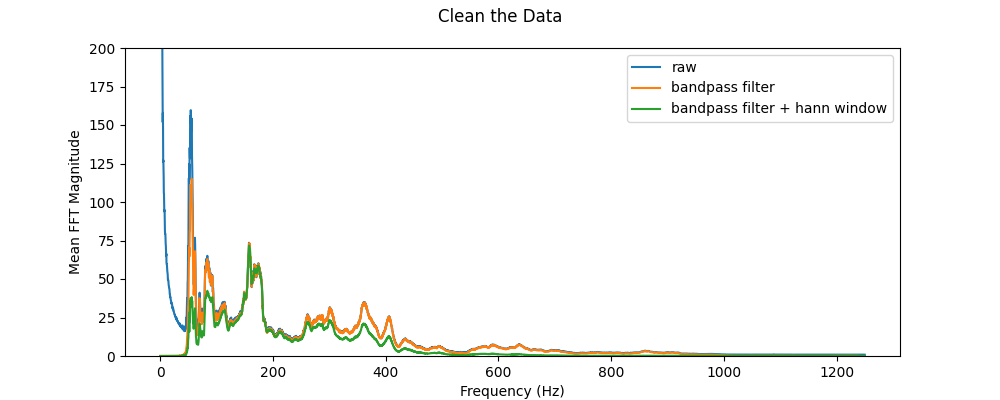

In [25]:
fig = plot_clean_data(d['shifts_raw'], d['fs'])
plt.show()

In [26]:
plt.close(fig)

Notice that there isn't really any signal after 500 hz so we'll crop it at 500 hz.

In [27]:
MIN_FREQ, MAX_FREQ = 50, 1_000

In [28]:
for name, d in data.items():
    d['shifts'] = clean_shifts(d['shifts_raw'], d['fs'])
    fft_val, freq = shifts_to_fft(d['shifts'], d['fs'], MIN_FREQ, MAX_FREQ)
    d['fft_vals'], d['freqs'] = fft_val, freq

In [29]:
list(d.keys())

['object',
 'x_position',
 'y_position',
 'position_xy',
 'position_idx',
 'duplicate_idx',
 'fs',
 'path',
 'shifts_raw',
 'time',
 'shifts',
 'fft_vals',
 'freqs']

In [30]:
d['shifts'].shape, d['shifts'].dtype

((100, 9000, 2), dtype('float64'))

In [31]:
d['time'].shape, d['time'].dtype

((9000,), dtype('float64'))

In [32]:
d['fft_vals'].shape, d['fft_vals'].dtype

((100, 3421, 2), dtype('complex128'))

In [33]:
d['freqs'].shape, d['freqs'].dtype

((3421,), dtype('float64'))

# 4. Compute Modes

In [34]:
from scipy.signal import find_peaks
from matplotlib.widgets import RangeSlider

In [35]:
def find_modes(freqs, fft_vals, n_modes=5, min_distance=100):
    """Find the top n_modes frequency peaks from mean FFT magnitude (averaged over lasers + x/y coordinate).

    Returns list of (frequency, magnitude, time) tuples sorted by frequency.
    Time is estimated assuming a log chirp from 50-2000 Hz over the recording duration.
    """

    mean_mag = fft_magnitude(fft_vals)
    peaks, _ = find_peaks(mean_mag, distance=min_distance)
    peak_mags = mean_mag[peaks]

    # Sort by magnitude and take top n_modes
    top_indices = np.argsort(peak_mags)[-n_modes:][::-1]
    mode_freqs_idx = np.array(sorted(peaks[top_indices]))

    mode_freqs = freqs[mode_freqs_idx]
    mode_fft_vals = fft_vals[:, mode_freqs_idx, :]
    return mode_freqs_idx, mode_freqs, mode_fft_vals

Let's compute the mode for each position by looking at the peaks of every FFT magnitude. Note: here each position has a different mode. We will "cannonacalize" the modes later.

Play around with the `n_samples`, `min_distance` parameters until they look right by inspecting the two plots.

In [36]:
# play around with these parameters until they look right using the plot_fft_by_position function
n_modes = 10
min_distance = 100

for name, d in data.items():
    mode_freqs_idx, mode_freqs, mode_fft_vals = find_modes(d['freqs'], d['fft_vals'], n_modes, min_distance)
    d['_mode_freqs_idx'], d['_mode_freqs'], d['_mode_fft_vals'] = mode_freqs_idx, mode_freqs, mode_fft_vals

In [37]:
d['_mode_fft_vals'].shape, d['_mode_fft_vals'].dtype

((100, 10, 2), dtype('complex128'))

In [38]:
d['_mode_freqs'].shape, d['_mode_freqs'].dtype

((10,), dtype('float64'))

In [39]:
d['_mode_freqs_idx'].shape, d['_mode_freqs_idx'].dtype

((10,), dtype('int64'))

## Visualize All Positions

Three visualization options:
1. **Heatmap** - Overview of all FFTs as colored rows (good for seeing patterns)
2. **Grid** - 8x10 small multiples showing each FFT shape
3. **Interactive** - Detailed view with position selector for comparing specific positions

In [40]:
def plot_fft_with_modes(data, mode_freq_key='_mode_freqs', mode_fft_vals_idx='_mode_fft_vals'):
    fig, axes = plt.subplots(2, 3, figsize=(15, 5))
    axes = axes.flatten()

    min_freq = min([min(d.get(mode_freq_key, d['freqs'].min())) for d in data.values()])
    max_freq = max([max(d.get(mode_freq_key, d['freqs'].max())) for d in data.values()])

    for d in data.values():
        # skip duplicates
        if d['duplicate_idx'] != 1: continue
        ax_idx = d['position'] - 1
        ax = axes[ax_idx]
        freqs, fft_vals = d['freqs'], d['fft_vals']

        mean, std = fft_magnitude(fft_vals, return_std=True)
        ax.plot(freq, mean, lw=0.8)
        ax.fill_between(freq, mean - std, mean + std, alpha=0.3)

        if mode_freq_key in d:
            for mode_freq, mode_fft_val in zip(d[mode_freq_key], d['_mode_fft_vals']):
                mode_fft_mag = fft_magnitude(mode_fft_val)
                ax.axvline(mode_freq, color='red', linestyle='--', alpha=0.7, lw=1)
                ax.scatter([mode_freq], [mode_fft_mag], color='red', s=50, zorder=5)
                ax.annotate(f'{mode_freq:.0f} Hz', (mode_freq, mode_fft_mag), textcoords='offset points',
                           xytext=(5, 5), fontsize=8, color='red')

        ax.set(title=f'Position {d['position']}', xlim=(min_freq*0.9, max_freq*1.1))
        ax.grid(True, alpha=0.3)
        n_modes = len(d[mode_freq_key])

    # 1. Set your labels as you did before
    for ax in axes[-3:]:
        ax.set_xlabel('Frequency (Hz)')

    for ax in axes[::3]:
        ax.set_ylabel('Magnitude')

    # 2. Clean up the ticks based on the presence of those labels
    for ax in axes.flatten():
        ax.tick_params(axis='x', labelbottom=bool(ax.get_xlabel()), bottom=bool(ax.get_xlabel()))
        ax.tick_params(axis='y', labelleft=bool(ax.get_ylabel()), left=bool(ax.get_ylabel()))


    plt.tight_layout(rect=[0, 0, 1, 0.95])
    title_suffix = f"\n{d[mode_freq_key]}" if 'cannonical' in mode_freq_key else ""
    fig.suptitle(f'FFT Magnitude {n_modes} modes'+title_suffix, fontsize=12)

    # Add range slider for frequency zoom
    ax_slider = fig.add_axes([0.15, 0.02, 0.7, 0.03])
    slider = RangeSlider(ax_slider, 'Freq (Hz)', freq.min(), freq.max(), valinit=(min_freq*0.9, max_freq*1.1))

    def update(val):
        freq_min, freq_max = val
        for ax in axes: ax.set_xlim(freq_min, freq_max)
        fig.canvas.draw_idle()
    slider.on_changed(update)

    # Keep a reference to the slider to prevent garbage collection
    fig._slider = slider
    return fig

In [41]:
def plot_fft_bubble(data, mode_freq_key='_mode_freqs'):
    """Bubble plot showing mode frequencies across all xy positions.

    X-axis: frequency (Hz)
    Y-axis: position (sorted by x,y with empty at top)
    Marker size: proportional to mean FFT magnitude at that mode (power-scaled for visibility)
    """
    fig, ax = plt.subplots(figsize=(14, 10))

    # Build position data sorted by coordinates
    positions_info = []  # list of (label, y_index, data_dict)
    for name, d in data.items():
        if d['duplicate_idx'] != 1:
            continue
        x, y = d.get('x_position'), d.get('y_position')
        if x is None or y is None:
            label = 'empty'
            sort_key = (-1, -1)  # empty goes first (will be at top after reversal)
        else:
            label = f'{x}x,{y}y'
            sort_key = (y, x)
        positions_info.append((label, sort_key, d))

    # Sort by y then x, empty first
    positions_info.sort(key=lambda p: (p[1][0] is not None, p[1][0] or 0, p[1][1] or 0))

    # Create y-index mapping (0 = bottom, higher = top, so empty ends up at top)
    label_to_yidx = {info[0]: i for i, info in enumerate(positions_info)}
    n_positions = len(positions_info)

    # Collect data for scatter
    y_indices = []
    frequencies = []
    magnitudes = []
    labels = []

    for label, _, d in positions_info:
        y_idx = label_to_yidx[label]
        if mode_freq_key not in d:
            continue
        for mode_freq, mode_fft_val in zip(d[mode_freq_key], d['_mode_fft_vals']):
            mag = fft_magnitude(mode_fft_val).item()
            y_indices.append(y_idx)
            frequencies.append(mode_freq)
            magnitudes.append(mag)
            labels.append(label)

    n_modes = len(d[mode_freq_key]) if mode_freq_key in d else 0
    y_indices = np.array(y_indices)
    frequencies = np.array(frequencies)
    magnitudes = np.array(magnitudes)

    # Draw horizontal lines for each position
    for i in range(n_positions):
        ax.axhline(i, color='gray', linestyle='-', alpha=0.3, linewidth=1)

    # Normalize magnitudes for marker sizes using power scaling (magnifies differences)
    sizes = np.power(magnitudes, 5) / np.power(magnitudes, 5).sum() * 10_000

    # Color by x-coordinate (even/odd) - for empty use a distinct color
    colors = []
    for label in labels:
        if label == 'empty':
            colors.append('tab:green')
        else:
            x_coord = int(label.split('x')[0])
            colors.append('tab:blue' if x_coord % 2 == 0 else 'tab:orange')

    scatter = ax.scatter(frequencies, y_indices, s=sizes, alpha=0.6,
                         c=colors, edgecolor='black', linewidth=0.5)

    # Add frequency labels on each bubble
    for freq, y_idx, mag in zip(frequencies, y_indices, magnitudes):
        ax.annotate(f'{freq:.0f}', (freq, y_idx), ha='center', va='center',
                    fontsize=6, fontweight='bold', color='black')

    ax.set_xlabel('Frequency (Hz)', fontsize=11)
    ax.set_ylabel('Position', fontsize=11)

    # Set y-ticks to position labels
    y_labels = [info[0] for info in positions_info]
    ax.set_yticks(range(n_positions))
    ax.set_yticklabels(y_labels, fontsize=7)

    ax.grid(True, alpha=0.3, axis='x')

    # Add color legend
    ax.scatter([], [], s=100, c='tab:blue', alpha=0.6, edgecolor='black', label='Even x-coord')
    ax.scatter([], [], s=100, c='tab:orange', alpha=0.6, edgecolor='black', label='Odd x-coord')
    ax.scatter([], [], s=100, c='tab:green', alpha=0.6, edgecolor='black', label='Empty')
    ax.legend(title='Position Type', loc='upper right', frameon=True)

    fig.suptitle(f'{n_modes} Mode Frequencies Across All Positions\n(marker size ~ mean FFT magnitude, power-scaled)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig

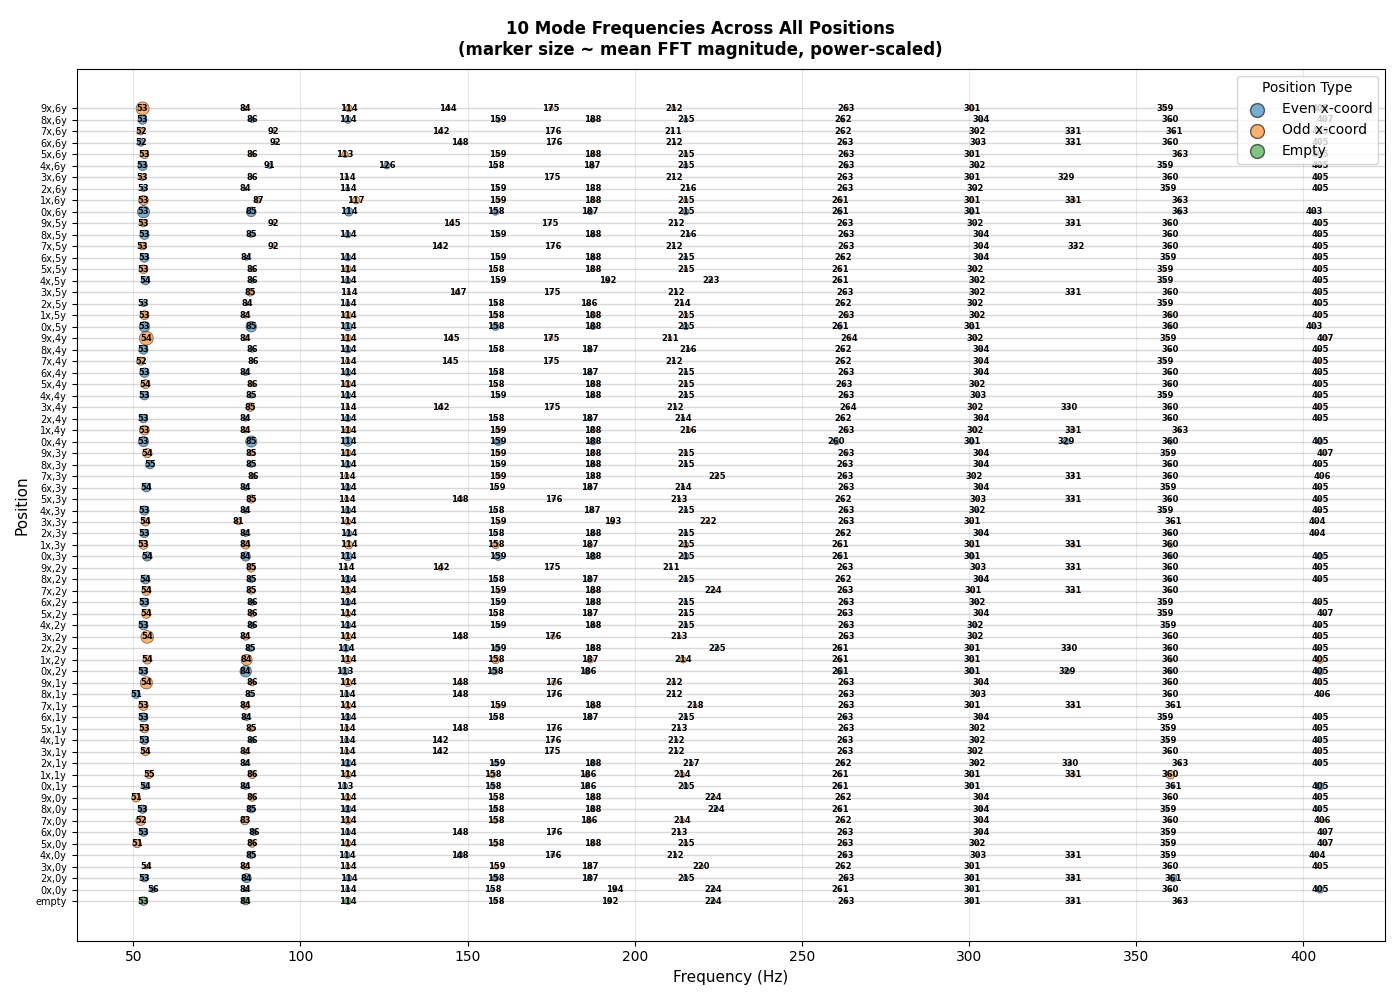

In [42]:
# Bubble plot: mode frequencies across all positions (marker size ~ FFT magnitude)
fig_bubble = plot_fft_bubble(data)
plt.show()

In [43]:
plt.close(fig_bubble)

In [44]:
def plot_fft_heatmap(data, log_scale=True, mode_freq_key='_mode_freqs'):
    """
    Heatmap showing FFT magnitude across all positions and frequencies.

    X-axis: Frequency (Hz)
    Y-axis: Position (sorted by x,y so spatial neighbors are adjacent)
    Color: Mean FFT magnitude (log scale by default)
    """
    # Filter: only duplicate_idx == 1, sort by (x_position, y_position)
    positions_data = []
    for name, d in data.items():
        if d['duplicate_idx'] != 1:
            continue
        positions_data.append({
            'name': name,
            'x': d.get('x_position'),
            'y': d.get('y_position'),
            'freqs': d['freqs'],
            'fft_vals': d['fft_vals'],
            'mode_freqs': d.get(mode_freq_key, [])
        })

    # Sort by y then x for spatial coherence (row-major order)
    # Put empty (x=None, y=None) at the beginning
    positions_data.sort(key=lambda p: (p['y'] is not None, p['y'] or 0, p['x'] or 0))

    # Build 2D array: (n_positions, n_frequencies)
    freq = positions_data[0]['freqs']
    n_positions = len(positions_data)
    n_freqs = len(freq)
    heatmap_data = np.zeros((n_positions, n_freqs))

    labels = []
    for i, p in enumerate(positions_data):
        mean_mag = fft_magnitude(p['fft_vals'])
        heatmap_data[i, :] = mean_mag
        if p['x'] is None:
            labels.append('empty')
        else:
            labels.append(f"{p['x']}x,{p['y']}y")

    # Apply log scale
    if log_scale:
        heatmap_data = np.log10(heatmap_data + 1)

    # Create figure
    fig, ax = plt.subplots(figsize=(14, 10))

    # Plot heatmap
    im = ax.imshow(heatmap_data, aspect='auto', cmap='viridis',
                   extent=[freq.min(), freq.max(), n_positions - 0.5, -0.5])

    # Y-axis labels (show every 5th for readability)
    ax.set_yticks(range(0, n_positions, 5))
    ax.set_yticklabels([labels[i] for i in range(0, n_positions, 5)])

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Log10(Magnitude + 1)' if log_scale else 'Magnitude')

    # Mark mode frequencies with vertical lines
    if positions_data[0]['mode_freqs'] is not None and len(positions_data[0]['mode_freqs']) > 0:
        for mode_freq in positions_data[0]['mode_freqs']:
            ax.axvline(mode_freq, color='red', linestyle='--', alpha=0.7, lw=1)

    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Position')
    ax.set_title('FFT Magnitude Heatmap Across All Positions')

    # Add frequency range slider
    ax_slider = fig.add_axes([0.15, 0.02, 0.7, 0.03])
    slider = RangeSlider(ax_slider, 'Freq (Hz)', freq.min(), freq.max(),
                         valinit=(freq.min(), freq.max()))

    def update(val):
        freq_min, freq_max = val
        ax.set_xlim(freq_min, freq_max)
        fig.canvas.draw_idle()
    slider.on_changed(update)

    fig._slider = slider
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    return fig

In [45]:
def plot_fft_grid(data, mode_freq_key='_mode_freqs'):
    """
    Grid of mini FFT plots: 8 rows x 10 columns.
    - Row 0 (top): Empty box in first cell, rest hidden
    - Rows 1-7: The 10x7 cube positions (y=0-6)

    Features:
    - Very compact subplots, shared axes
    - Only edge subplots have axis labels
    - Subplot title shows position coords
    - RangeSlider for frequency zoom
    - Mode frequencies marked with red vertical lines
    """
    # Build position lookup: (x, y) -> data dict
    position_lookup = {}
    empty_data = None
    freq = None

    for name, d in data.items():
        if d['duplicate_idx'] != 1:
            continue
        if freq is None:
            freq = d['freqs']
        x, y = d.get('x_position'), d.get('y_position')
        if x is None or y is None:
            empty_data = d
        else:
            position_lookup[(x, y)] = d

    # Get mode frequencies from first available position
    mode_freqs = []
    if empty_data and mode_freq_key in empty_data:
        mode_freqs = empty_data[mode_freq_key]
    elif position_lookup and mode_freq_key in list(position_lookup.values())[0]:
        mode_freqs = list(position_lookup.values())[0][mode_freq_key]

    # Create 8x10 grid
    fig, axes = plt.subplots(8, 10, figsize=(20, 12), sharex=True, sharey=True)

    # Compute global y limits for consistent scaling
    all_means = []
    for d in [empty_data] + list(position_lookup.values()):
        if d is not None:
            all_means.append(fft_magnitude(d['fft_vals']))
    y_max = max(m.max() for m in all_means) * 1.1

    # Row 0: empty box in first cell, hide the rest
    if empty_data is not None:
        ax = axes[0, 0]
        mean_mag = fft_magnitude(empty_data['fft_vals'])
        ax.plot(freq, mean_mag, lw=0.5, color='C0')
        ax.set_title('empty', fontsize=7)
        for mf in mode_freqs:
            ax.axvline(mf, color='red', linestyle='--', alpha=0.5, lw=0.5)

    # Hide remaining cells in row 0
    for j in range(1, 10):
        axes[0, j].axis('off')

    # Rows 1-7: cube positions (y=0 to y=6)
    for y in range(7):
        for x in range(10):
            ax = axes[y + 1, x]
            if (x, y) in position_lookup:
                d = position_lookup[(x, y)]
                mean_mag = fft_magnitude(d['fft_vals'])
                ax.plot(freq, mean_mag, lw=0.5, color='C0')
                ax.set_title(f'{x}x,{y}y', fontsize=7)
                for mf in mode_freqs:
                    ax.axvline(mf, color='red', linestyle='--', alpha=0.5, lw=0.5)
            else:
                ax.set_title(f'{x}x,{y}y', fontsize=7, color='gray')
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes, color='gray')

    # Set y limits
    for ax in axes.flatten():
        ax.set_ylim(0, y_max)

    # Only show axis labels on edges
    for ax in axes[-1, :]:  # bottom row
        ax.set_xlabel('Freq', fontsize=7)
    for ax in axes[:, 0]:   # left column
        ax.set_ylabel('Mag', fontsize=7)

    # Clean up tick labels for compactness
    for ax in axes.flatten():
        ax.tick_params(axis='both', labelsize=5, length=2)

    plt.tight_layout(rect=[0, 0.05, 1, 0.98])
    fig.suptitle('FFT Grid: All Positions (8 rows x 10 cols)', fontsize=12)

    # Add frequency range slider
    ax_slider = fig.add_axes([0.15, 0.01, 0.7, 0.02])
    slider = RangeSlider(ax_slider, 'Freq', freq.min(), freq.max(),
                         valinit=(freq.min(), freq.max()))

    def update(val):
        freq_min, freq_max = val
        for ax in axes.flatten():
            ax.set_xlim(freq_min, freq_max)
        fig.canvas.draw_idle()
    slider.on_changed(update)

    fig._slider = slider
    return fig

In [46]:
def plot_fft_interactive(data, mode_freq_key='_mode_freqs', show_std=False):
    """
    Interactive FFT plot with dropdown to select position(s).

    Features:
    - Dropdown menu listing all positions (sorted)
    - Multi-select to compare 2-3 positions
    - Full detailed FFT with mean +/- std shading (optional)
    - Mode frequency markers
    - RangeSlider for frequency zoom
    - Preserves zoom level when changing position selection

    Args:
        data: dict of experiment data
        mode_freq_key: key for mode frequencies in data
        show_std: if True, show std shading around mean (default: False)
    """
    import ipywidgets as widgets
    from IPython.display import display

    # Build sorted list of positions
    positions = []
    position_data = {}
    freq = None

    for name, d in data.items():
        if d['duplicate_idx'] != 1:
            continue
        if freq is None:
            freq = d['freqs']
        x, y = d.get('x_position'), d.get('y_position')
        if x is None or y is None:
            label = 'empty'
        else:
            label = f'{x}x,{y}y'
        positions.append(label)
        position_data[label] = d

    # Sort positions: empty first, then by coordinates
    positions.sort(key=lambda p: (p != 'empty', int(p.split('x')[0]) if p != 'empty' else -1,
                                   int(p.split(',')[1].replace('y', '')) if p != 'empty' else -1))

    # Get mode frequencies
    mode_freqs = []
    if mode_freq_key in list(position_data.values())[0]:
        mode_freqs = list(position_data.values())[0][mode_freq_key]

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6))

    # Multi-select widget
    selector = widgets.SelectMultiple(
        options=positions,
        value=[positions[1]] if len(positions) > 1 else [positions[0]],
        description='Positions:',
        rows=10,
        layout=widgets.Layout(width='150px')
    )

    # Color cycle for multiple selections
    colors = plt.cm.tab10.colors

    def update_plot(selected_positions):
        # Save current xlim before clearing
        current_xlim = ax.get_xlim()

        ax.clear()

        for i, pos in enumerate(selected_positions):
            d = position_data[pos]
            mean, std = fft_magnitude(d['fft_vals'], return_std=True)
            color = colors[i % len(colors)]
            ax.plot(freq, mean, lw=1, color=color, label=pos)
            if show_std:
                ax.fill_between(freq, mean - std, mean + std, alpha=0.2, color=color)

        # Mark mode frequencies
        for mf in mode_freqs:
            ax.axvline(mf, color='red', linestyle='--', alpha=0.5, lw=1)

        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('FFT Magnitude')
        ax.set_title(f'FFT Comparison: {", ".join(selected_positions)}')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

        # Restore xlim if it was set (not the default 0-1 from empty axes)
        if current_xlim != (0.0, 1.0):
            ax.set_xlim(current_xlim)

        fig.canvas.draw_idle()

    def on_change(change):
        if change['name'] == 'value':
            update_plot(list(change['new']))

    selector.observe(on_change)

    # Initial plot
    update_plot(list(selector.value))

    # Add frequency range slider
    ax_slider = fig.add_axes([0.15, 0.02, 0.7, 0.03])
    slider = RangeSlider(ax_slider, 'Freq (Hz)', freq.min(), freq.max(),
                         valinit=(freq.min(), freq.max()))

    def update_range(val):
        ax.set_xlim(val)
        fig.canvas.draw_idle()
    slider.on_changed(update_range)

    fig._slider = slider
    fig._selector = selector
    plt.tight_layout(rect=[0, 0.05, 1, 1])

    display(selector)
    return fig

In [47]:
# Heatmap: overview of all positions
# fig_heatmap = plot_fft_heatmap(data)

In [48]:
# Grid: 8x10 small multiples (empty box at top-left, cube positions below)
# fig_grid = plot_fft_grid(data)

/var/folders/f6/vzqh7ynx4n3ft_sx36yv3gbm0000gn/T/ipykernel_59861/4149032459.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 1])


SelectMultiple(description='Positions:', index=(1,), layout=Layout(width='150px'), options=('empty', '0x,0y', …

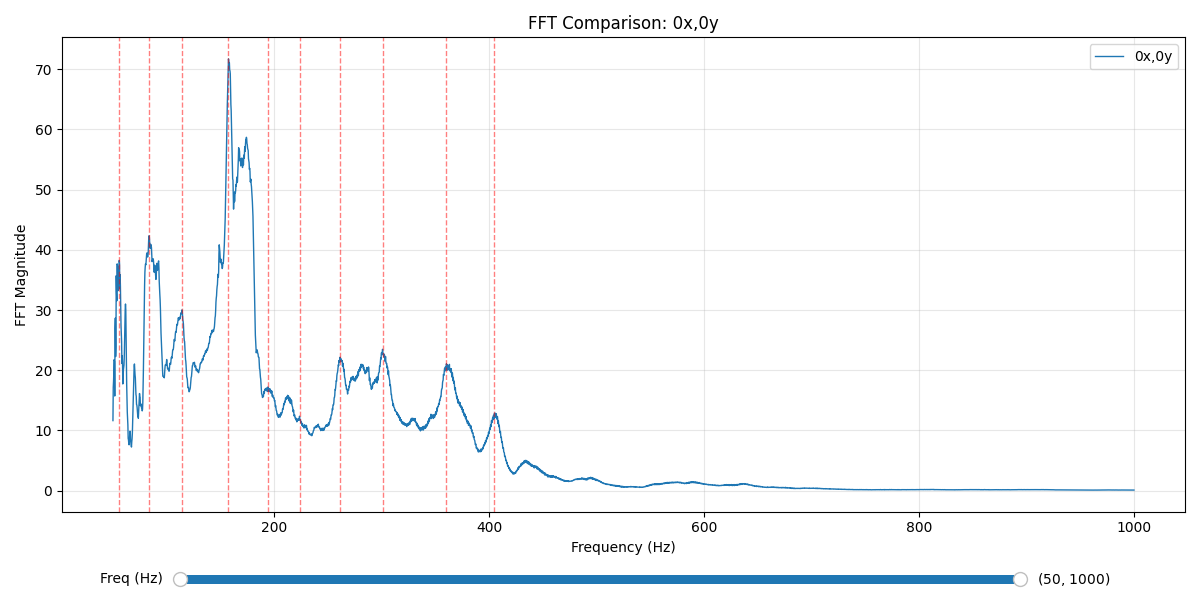

In [49]:
# Interactive: select positions to compare (use Ctrl/Cmd+click for multi-select)
fig_interactive = plot_fft_interactive(data)

Based on our graphs, let's define our canonical modes as the modes from position 3. The canonical modes do not have a '_' in their key names.

### Compute Canonical Mode Frequencies from All Positions

Based on visual inspection of the bubble plot, we identified approximate mode frequencies: `[53, 85, 158, 186, 213, 262, 302, 330, 359, 405]`.

For each target frequency, we:
1. Loop over all positions
2. Find if there's a detected mode within ±10 Hz of the target
3. Collect all matching mode frequencies
4. Compute the **median** as the canonical mode frequency

This gives us robust canonical modes based on all positions, not just one.

In [50]:
def compute_canonical_modes(data, target_freqs, tolerance=10, mode_freq_key='_mode_freqs'):
    """Compute canonical mode frequencies by finding median across all positions.

    Args:
        data: dict of experiment data
        target_freqs: list of approximate mode frequencies from visual inspection
        tolerance: +/- Hz tolerance for matching (default: 10)
        mode_freq_key: key for mode frequencies in data

    Returns:
        canonical_modes: list of median frequencies for each target
        matches_per_mode: dict mapping target freq -> list of matching freqs from all positions
    """
    matches_per_mode = {target: [] for target in target_freqs}

    for name, d in data.items():
        if d['duplicate_idx'] != 1:
            continue
        if mode_freq_key not in d:
            continue

        mode_freqs = d[mode_freq_key]

        for target in target_freqs:
            # Find modes within tolerance of this target
            for mode_freq in mode_freqs:
                if abs(mode_freq - target) <= tolerance:
                    matches_per_mode[target].append(mode_freq)

    # Compute median for each target
    canonical_modes = []
    print(f"{'Target':>8} | {'Matches':>8} | {'Median':>10} | {'Std':>8}")
    print("-" * 45)
    for target in target_freqs:
        matches = matches_per_mode[target]
        if len(matches) > 0:
            median_freq = np.median(matches)
            std_freq = np.std(matches)
            canonical_modes.append(median_freq)
            print(f"{target:>8} | {len(matches):>8} | {median_freq:>10.2f} | {std_freq:>8.2f}")
        else:
            canonical_modes.append(target)  # fallback to target if no matches
            print(f"{target:>8} | {0:>8} | {target:>10.2f} | {'N/A':>8}")

    return np.array(canonical_modes), np.array(matches_per_mode)

In [51]:
# Target frequencies from visual inspection of bubble plot
target_freqs = [53, 85, 158, 186, 213, 262, 302, 330, 359, 405]

# Compute canonical modes as median across all positions
canonical_mode_freqs, matches_per_mode = compute_canonical_modes(data, target_freqs, tolerance=10)

print(f"\nCanonical mode frequencies:")
for i in range(len(canonical_mode_freqs)):
    print(f"{i}\t{canonical_mode_freqs[i]}")

  Target |  Matches |     Median |      Std
---------------------------------------------
      53 |       62 |      53.33 |     0.81
      85 |       70 |      85.28 |     2.10
     158 |       50 |     158.33 |     0.48
     186 |       50 |     187.50 |     1.69
     213 |       61 |     215.28 |     2.30
     262 |       70 |     263.06 |     0.82
     302 |       70 |     302.50 |     1.08
     330 |       23 |     331.11 |     0.71
     359 |       70 |     360.28 |     1.12
     405 |       62 |     405.00 |     0.64

Canonical mode frequencies:
0	53.333333333333336
1	85.27777777777779
2	158.33333333333334
3	187.5
4	215.2777777777778
5	263.05555555555554
6	302.5
7	331.11111111111114
8	360.27777777777777
9	405.0


In [52]:
for name, d in data.items():
    # Store the canonical frequencies
    d['mode_freqs'] = canonical_mode_freqs

    # Find the closest frequency index in THIS position's frequency array for each canonical mode frequency
    freq_indices = []
    for target_freq in canonical_mode_freqs:
        idx = np.argmin(np.abs(d['freqs'] - target_freq))
        freq_indices.append(idx)

    d['mode_freqs_idx'] = np.array(freq_indices)

    # Extract FFT values at those indices from THIS position's fft_vals
    d['mode_fft_vals'] = d['fft_vals'][:, freq_indices, :]

# 5. Sync Phases

In [53]:
def sync_phases(fft_vals, laser_idx=0, xy_idx=0, eps=1e-20):
    fft_vals_synced = fft_vals.copy()             # copy
    ref = fft_vals[laser_idx, :, xy_idx]          # shape (freq,)
    phase = np.conj(ref) / (np.abs(ref)**2 + eps) # unit complex + divide by magnitude
    fft_vals_synced *= phase[None, :, None]       # broadcast over lasers and xy
    assert np.allclose(1, np.real(fft_vals_synced[laser_idx, :, xy_idx])) # check we have magnitude 1
    return fft_vals_synced # (n_lasers, n_freqs, 2)

In [54]:
def get_gradients(fft_vals, n_lasers):
    """Extract real-valued gradients from complex FFT values, reshaped to (n_modes, 2, grid, grid).

    Args:
        fft_vals: shape (n_lasers^2, n_modes, 2) - complex FFT values
        n_lasers: grid dimension (e.g., 10 for 10x10 grid)

    Returns:
        gradients: shape (n_modes, 2, n_lasers, n_lasers) - real-valued gradients
                   Access as gradients[mode_idx, 0] for dx, gradients[mode_idx, 1] for dy
    """
    fft_vals = np.real(fft_vals)  # shape: (100, n_modes, 2)
    # Reshape: (100, n_modes, 2) -> (10, 10, n_modes, 2) -> (n_modes, 2, 10, 10)
    gradients = fft_vals.reshape(n_lasers, n_lasers, -1, 2)
    gradients = gradients.transpose(2, 3, 0, 1)  # (n_modes, 2, n_lasers, n_lasers)
    return gradients

In [55]:
for name, d in data.items():
    d['synced_fft_vals'] = sync_phases(d['fft_vals'])
    d['synced_mode_fft_vals'] = sync_phases(d['mode_fft_vals'])

In [56]:
d['synced_fft_vals'].shape, d['synced_fft_vals'].dtype

((100, 3421, 2), dtype('complex128'))

In [57]:
d['synced_mode_fft_vals'].shape, d['synced_mode_fft_vals'].dtype

((100, 10, 2), dtype('complex128'))

In [58]:
for name, d in data.items():
    n_lasers = int(np.sqrt(d['shifts'].shape[0]))
    d['mode_fft_gradients'] = get_gradients(d['mode_fft_vals'], n_lasers)  # shape: (n_freqs, 2, 10, 10)
    d['synced_fft_gradients'] = get_gradients(d['synced_fft_vals'], n_lasers)  # shape: (n_freqs, 2, 10, 10)
    d['synced_mode_fft_gradients'] = get_gradients(d['synced_mode_fft_vals'], n_lasers)  # shape: (n_modes, 2, 10, 10)

In [59]:
d['mode_fft_gradients'].shape, d['mode_fft_gradients'].dtype

((10, 2, 10, 10), dtype('float64'))

In [60]:
d['synced_fft_gradients'].shape, d['synced_fft_gradients'].dtype

((3421, 2, 10, 10), dtype('float64'))

In [61]:
d['synced_mode_fft_gradients'].shape, d['synced_mode_fft_gradients'].dtype

((10, 2, 10, 10), dtype('float64'))

## Visualize Gradients

Visualize the mode shapes as quiver plots. Each subplot shows one mode, and you can toggle different box positions on/off to compare their vibration patterns.

In [85]:
from matplotlib.widgets import Button
import matplotlib.colors as mcolors

# Color palette for sequential distinct colors
SEQUENTIAL_COLORS = list(mcolors.TABLEAU_COLORS.values())  # 10 distinct colors


def interactive_gradient_explorer(data, initial_mode_idx=0):
    """
    Interactive visualization of gradients with click-to-select box positions.

    Left plot: 10x10 laser grid showing quiver arrows for selected positions.
    Right plot: 10x7 clickable grid for box positions + Empty row below.

    Args:
        data: dict of experiment data with 'synced_mode_fft_gradients'
        initial_mode_idx: initial mode to display (0-indexed)

    Returns:
        fig: matplotlib figure with interactive controls
    """
    from ipywidgets import Dropdown, HBox, Label, Output
    from IPython.display import display, clear_output

    # Build position lookup: (x, y) -> data entry
    pos_to_data = {}
    empty_data = None

    for name, d in data.items():
        if d.get('duplicate_idx', 1) != 1:
            continue  # skip duplicates
        if 'synced_mode_fft_gradients' not in d:
            continue

        x, y = d.get('x_position'), d.get('y_position')
        if x is None or y is None:
            empty_data = d
        else:
            pos_to_data[(x, y)] = d

    # Get dimensions from first valid entry
    d0 = next(d for d in data.values() if 'synced_mode_fft_gradients' in d and d.get('duplicate_idx', 1) == 1)
    n_modes = d0['synced_mode_fft_gradients'].shape[0]
    n_lasers = d0['synced_mode_fft_gradients'].shape[2]  # 10
    mode_freqs = d0.get('mode_freqs', list(range(n_modes)))

    # Grid coordinates for laser plot
    X_laser, Y_laser = np.meshgrid(np.arange(n_lasers), np.arange(n_lasers))

    # Box grid dimensions
    n_box_x, n_box_y = 10, 7  # x: 0-9, y: 0-6

    # State
    state = {
        'current_mode': initial_mode_idx,
        'active_positions': set(),  # set of (x, y) tuples
        'empty_active': False,
        'color_idx': 0,  # for assigning colors
        'pos_colors': {},  # (x,y) or 'empty' -> color
        'pos_labels': [],  # text objects for colored position labels
    }
    quivers = {}  # key -> quiver object

    # Create dropdown for mode selection
    mode_options = [(f'Mode {i+1}: {mode_freqs[i]:.1f} Hz', i) for i in range(n_modes)]
    mode_dropdown = Dropdown(
        options=mode_options,
        value=initial_mode_idx,
        description='Select Mode:',
        style={'description_width': 'auto'},
        layout={'width': '250px'}
    )

    # Create figure
    fig = plt.figure(figsize=(14, 6))

    # Layout with GridSpec
    gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1],
                          top=0.88, bottom=0.08, left=0.06, right=0.95, wspace=0.15)

    # Left plot: laser gradients (quiver)
    ax_laser = fig.add_subplot(gs[0, 0])
    ax_laser.set_xlim(-1.5, n_lasers + 0.5)
    ax_laser.set_ylim(-1.5, n_lasers + 0.5)
    ax_laser.set_aspect('equal')
    ax_laser.set_xlabel('Laser X')
    ax_laser.set_ylabel('Laser Y')
    ax_laser.grid(True, alpha=0.3, linestyle='--')
    ax_laser.set_xticks(range(n_lasers))
    ax_laser.set_yticks(range(n_lasers))

    # Title text object for laser plot (will be updated with mode info)
    title_text = ax_laser.set_title(f'Mode {initial_mode_idx+1}: {mode_freqs[initial_mode_idx]:.1f} Hz',
                                     fontsize=12, fontweight='bold')

    # Right side: box grid with Empty row at bottom (y = -1)
    ax_grid = fig.add_subplot(gs[0, 1])
    ax_grid.set_xlim(-0.5, n_box_x - 0.5)
    ax_grid.set_ylim(-1.8, n_box_y - 0.5)  # Extended down for empty row
    ax_grid.set_aspect('equal')
    ax_grid.set_xlabel('Box X Position')
    ax_grid.set_ylabel('Box Y Position')
    ax_grid.set_title('Click to Select Box Positions', fontsize=11)
    ax_grid.set_xticks(range(n_box_x))
    ax_grid.set_yticks(range(-1, n_box_y))
    ax_grid.set_yticklabels(['Empty'] + [str(i) for i in range(n_box_y)])

    # Draw grid cells as rectangles (for highlighting)
    grid_rects = {}
    for x in range(n_box_x):
        for y in range(n_box_y):
            if (x, y) in pos_to_data:
                rect = plt.Rectangle((x - 0.5, y - 0.5), 1, 1,
                                     facecolor='#e0e0e0', edgecolor='#888888', linewidth=0.5)
                ax_grid.add_patch(rect)
                grid_rects[(x, y)] = rect
            else:
                # Position not in data - mark as unavailable
                rect = plt.Rectangle((x - 0.5, y - 0.5), 1, 1,
                                     facecolor='#f8f8f8', edgecolor='#cccccc', linewidth=0.5, hatch='//')
                ax_grid.add_patch(rect)

    # Empty row - spans full width at y = -1
    empty_rect = plt.Rectangle((-0.5, -1.5), n_box_x, 1,
                               facecolor='#d0d0d0', edgecolor='#888888', linewidth=1)
    ax_grid.add_patch(empty_rect)

    # Add "EMPTY" label in the center of the empty row
    ax_grid.text(n_box_x / 2 - 0.5, -1, 'EMPTY', ha='center', va='center',
                fontsize=10, fontweight='bold', color='#555555')

    # Add subtle separator line between empty row and grid
    ax_grid.axhline(y=-0.5, color='#666666', linewidth=1.5, linestyle='-')

    def get_next_color():
        color = SEQUENTIAL_COLORS[state['color_idx'] % len(SEQUENTIAL_COLORS)]
        state['color_idx'] += 1
        return color

    def compute_scale():
        """Compute quiver scale from active data."""
        mode_idx = state['current_mode']
        max_mag = 0

        for pos in state['active_positions']:
            if pos in pos_to_data:
                d = pos_to_data[pos]
                dx = d['synced_mode_fft_gradients'][mode_idx, 0]
                dy = d['synced_mode_fft_gradients'][mode_idx, 1]
                max_mag = max(max_mag, np.max(np.sqrt(dx**2 + dy**2)))

        if state['empty_active'] and empty_data is not None:
            dx = empty_data['synced_mode_fft_gradients'][mode_idx, 0]
            dy = empty_data['synced_mode_fft_gradients'][mode_idx, 1]
            max_mag = max(max_mag, np.max(np.sqrt(dx**2 + dy**2)))

        return max_mag / 0.2 if max_mag > 0 else 1.0

    def draw_quivers():
        """Redraw all quivers for active positions."""
        # Clear existing quivers
        for q in quivers.values():
            q.remove()
        quivers.clear()

        # Update title with current mode
        mode_idx = state['current_mode']
        # Build title with mode and colored position labels inline
        # Clear old position labels
        for txt in state.get('pos_labels', []):
            txt.remove()
        state['pos_labels'] = []

        # Base title: "Mode X: YYY Hz | Positions: "
        base_title = f"Mode {mode_idx+1}: {mode_freqs[mode_idx]:.1f} Hz  |  Positions: "
        title_text.set_text(base_title)

        # Add colored position labels inline after the title
        if state['active_positions'] or state['empty_active']:
            label_colors = []
            for pos in sorted(state['active_positions']):
                color = state['pos_colors'].get(pos, 'blue')
                label_colors.append((f'({pos[0]},{pos[1]})', color))
            if state['empty_active']:
                color = state['pos_colors'].get('empty', 'gray')
                label_colors.append(('Empty', color))

            # Place colored labels using axes transform, inline after title
            x_start = 0.80  # Start position after "Positions: " in axes fraction
            for j, (label, color) in enumerate(label_colors):
                space = ' ' if j < len(label_colors) - 1 else ''
                txt = ax_laser.text(x_start, 1.01, label + space, transform=ax_laser.transAxes,
                                   ha='left', va='bottom', fontsize=12, fontweight='bold', color=color)
                state['pos_labels'].append(txt)
                x_start += len(label + space) * 0.018  # Advance for next label
        else:
            txt = ax_laser.text(0.80, 1.01, 'None', transform=ax_laser.transAxes,
                               ha='left', va='bottom', fontsize=12, fontstyle='italic', color='gray')
            state['pos_labels'].append(txt)

        if not state['active_positions'] and not state['empty_active']:
            fig.canvas.draw_idle()
            return

        scale = compute_scale()

        # Draw quivers for active box positions
        for pos in state['active_positions']:
            if pos not in pos_to_data:
                continue
            d = pos_to_data[pos]
            color = state['pos_colors'].get(pos, 'blue')

            dx = d['synced_mode_fft_gradients'][mode_idx, 0]
            dy = d['synced_mode_fft_gradients'][mode_idx, 1]

            q = ax_laser.quiver(X_laser, Y_laser, dx, dy, scale=scale, color=color, alpha=0.7)
            quivers[pos] = q

        # Draw quiver for empty if active
        if state['empty_active'] and empty_data is not None:
            color = state['pos_colors'].get('empty', 'gray')
            dx = empty_data['synced_mode_fft_gradients'][mode_idx, 0]
            dy = empty_data['synced_mode_fft_gradients'][mode_idx, 1]

            q = ax_laser.quiver(X_laser, Y_laser, dx, dy, scale=scale, color=color, alpha=0.7)
            quivers['empty'] = q

        fig.canvas.draw_idle()

    def toggle_position(pos):
        """Toggle a box position on/off."""
        if pos in state['active_positions']:
            # Deactivate
            state['active_positions'].remove(pos)
            if pos in state['pos_colors']:
                del state['pos_colors'][pos]
            # Reset rectangle color
            if pos in grid_rects:
                grid_rects[pos].set_facecolor('#e0e0e0')
        else:
            # Activate
            if pos in pos_to_data:
                state['active_positions'].add(pos)
                color = get_next_color()
                state['pos_colors'][pos] = color
                # Highlight rectangle
                if pos in grid_rects:
                    grid_rects[pos].set_facecolor(color)

        draw_quivers()

    def toggle_empty():
        """Toggle empty position on/off."""
        if state['empty_active']:
            state['empty_active'] = False
            if 'empty' in state['pos_colors']:
                del state['pos_colors']['empty']
            empty_rect.set_facecolor('#d0d0d0')
        else:
            state['empty_active'] = True
            color = get_next_color()
            state['pos_colors']['empty'] = color
            empty_rect.set_facecolor(color)

        draw_quivers()

    def on_mode_change(change):
        """Handle dropdown mode selection change."""
        state['current_mode'] = change['new']
        draw_quivers()

    def on_click(event):
        """Handle click on grid."""
        if event.inaxes != ax_grid:
            return
        if event.xdata is None or event.ydata is None:
            return

        x_idx = int(round(event.xdata))
        y_idx = int(round(event.ydata))

        # Check if clicking on empty row (y around -1)
        if -1.5 <= event.ydata <= -0.5:
            toggle_empty()
            return

        # Check bounds for regular grid
        if 0 <= x_idx < n_box_x and 0 <= y_idx < n_box_y:
            pos = (x_idx, y_idx)
            if pos in pos_to_data:
                toggle_position(pos)

    # Connect event handlers
    mode_dropdown.observe(on_mode_change, names='value')
    fig.canvas.mpl_connect('button_press_event', on_click)

    # Store references to prevent garbage collection
    fig._widgets = {
        'mode_dropdown': mode_dropdown,
        'grid_rects': grid_rects,
        'empty_rect': empty_rect,
    }
    fig._state = state
    fig._quivers = quivers

    # Display dropdown widget above the figure
    display(mode_dropdown)

    return fig


Dropdown(description='Select Mode:', layout=Layout(width='250px'), options=(('Mode 1: 53.3 Hz', 0), ('Mode 2: …

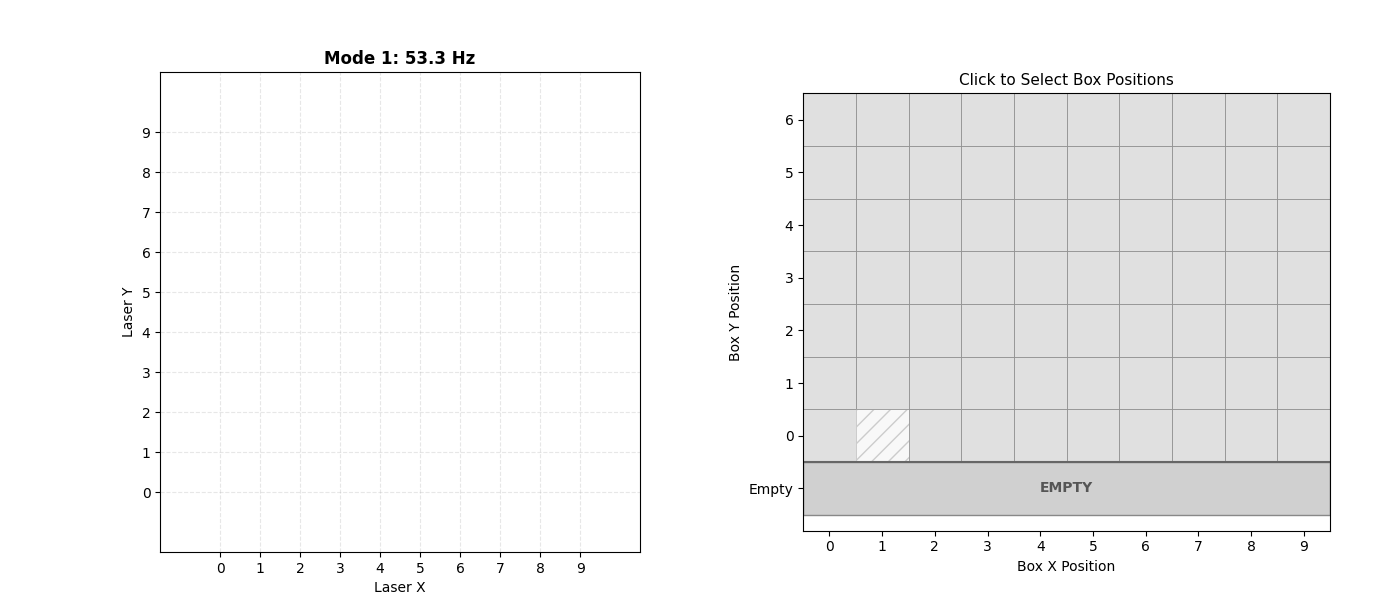

In [86]:
# Interactive gradient explorer - click on box positions to compare gradients
fig = interactive_gradient_explorer(data)
plt.show()

## Old 

In [64]:
from matplotlib.widgets import CheckButtons

# Color palette for positions
POSITION_COLORS = {
    1: '#1f77b4',  # blue
    2: '#ff7f0e',  # orange
    3: '#2ca02c',  # green
    4: '#d62728',  # red
    5: '#9467bd',  # purple
    6: '#8c564b',  # brown
}


def plot_mode_quivers(data, n_cols=3, scale_per_mode=False):
    """
    Interactive quiver plot showing mode shapes for all positions.

    Each subplot = one mode. Toggle positions on/off with checkboxes.
    Quiver arrows show (dx, dy) shifts at each laser point for that mode.

    Args:
        data: dict of experiment data
        n_cols: number of columns in subplot grid
        scale_per_mode: if True, each mode is scaled independently for better visibility
    """
    # Get positions (skip duplicates)
    positions = sorted(set(d['position'] for d in data.values() if d['duplicate_idx'] == 1))

    # Get dimensions from first entry
    d0 = next(d for d in data.values() if d['duplicate_idx'] == 1)
    n_modes = len(d0['mode_freqs'])
    n_lasers = int(np.sqrt(d0['shifts'].shape[0]))
    mode_freqs = d0['mode_freqs']

    # Grid coordinates
    X, Y = np.meshgrid(np.arange(n_lasers), np.arange(n_lasers))

    # Setup figure with space for horizontal checkbox bar at top
    n_rows = int(np.ceil(n_modes / n_cols))
    fig = plt.figure(figsize=(3.2*n_cols, 3*n_rows))
    fig.suptitle('Mode Shapes by Position', fontsize=14, fontweight='bold', y=0.98)

    # Leave space at top for title and checkboxes
    gs = fig.add_gridspec(n_rows, n_cols, top=0.85, bottom=0.05, left=0.08, right=0.95, hspace=0.35, wspace=0.25)
    axes = [fig.add_subplot(gs[i // n_cols, i % n_cols]) for i in range(n_modes)]

    # Configure mode axes
    for i, ax in enumerate(axes):
        ax.set_xlim(-0.5, n_lasers - 0.5)
        ax.set_ylim(-0.5, n_lasers - 0.5)
        ax.set_aspect('equal')
        ax.set_title(f'Mode {i+1}: {mode_freqs[i]:.1f} Hz')
        ax.grid(True, alpha=0.3, linestyle='--')

    # State tracking
    active = {pos: True for pos in positions}
    quivers = {}  # (mode_idx, position) -> quiver object

    def compute_scale():
        """Compute quiver scale from active data."""
        if scale_per_mode:
            # Separate scale per mode
            scales = {}
            for mode_idx in range(n_modes):
                max_mag = 0
                for pos in positions:
                    if not active[pos]:
                        continue
                    d = next(d for d in data.values() if d['position'] == pos and d['duplicate_idx'] == 1)
                    dx = d['synced_mode_fft_gradients'][mode_idx, 0]
                    dy = d['synced_mode_fft_gradients'][mode_idx, 1]
                    max_mag = max(max_mag, np.max(np.sqrt(dx**2 + dy**2)))
                scales[mode_idx] = max_mag / 0.2 if max_mag > 0 else 1.0
            return scales
        else:
            # Global scale: max across all modes and positions
            max_mag = 0
            for pos in positions:
                if not active[pos]:
                    continue
                d = next(d for d in data.values() if d['position'] == pos and d['duplicate_idx'] == 1)
                for mode_idx in range(n_modes):
                    dx = d['synced_mode_fft_gradients'][mode_idx, 0]
                    dy = d['synced_mode_fft_gradients'][mode_idx, 1]
                    max_mag = max(max_mag, np.max(np.sqrt(dx**2 + dy**2)))
            return max_mag / 0.2 if max_mag > 0 else 1.0

    def draw():
        """Redraw all quivers."""
        # Clear existing
        for q in quivers.values(): q.remove()
        quivers.clear()

        if not any(active.values()):
            fig.canvas.draw_idle()
            return

        scale = compute_scale()
        print(f'{scale=}')

        # Draw quivers for active positions
        for pos in positions:
            if not active[pos]:
                continue
            d = next(d for d in data.values() if d['position'] == pos and d['duplicate_idx'] == 1)
            color = POSITION_COLORS[pos]

            for mode_idx, ax in enumerate(axes):
                # Gradients shape: (n_modes, 2, n_lasers, n_lasers)
                dx = d['synced_mode_fft_gradients'][mode_idx, 0]
                dy = d['synced_mode_fft_gradients'][mode_idx, 1]

                # Get scale for this mode (dict for per_mode, float otherwise)
                mode_scale = scale[mode_idx] if isinstance(scale, dict) else scale

                q = ax.quiver(X, Y, dx, dy, scale=mode_scale, color=color, alpha=0.7)
                quivers[(mode_idx, pos)] = q

        fig.canvas.draw_idle()

    # Add horizontal checkbox bar at top (below title)
    n_pos = len(positions)
    ax_check = fig.add_axes([0.1, 0.89, 0.8, 0.06])
    ax_check.set_frame_on(False)

    labels = [f'Pos {p}' for p in positions]
    check = CheckButtons(ax_check, labels, [True] * n_pos)

    # Reposition checkboxes horizontally
    horizontal_positions = []
    for i in range(n_pos):
        x_pos = (i + 0.5) / n_pos
        horizontal_positions.append([x_pos - 0.05, 0.5])

    # Move frames and checks
    check._frames.set_offsets(horizontal_positions)
    check._checks.set_offsets(horizontal_positions)

    # Move and color labels
    for i, (label, pos) in enumerate(zip(check.labels, positions)):
        x_pos = (i + 0.5) / n_pos
        label.set_position((x_pos + 0.02, 0.5))
        label.set_color(POSITION_COLORS[pos])
        label.set_fontweight('bold')
        label.set_fontsize(10)

    def on_click(label):
        pos = int(label.split()[-1])
        active[pos] = not active[pos]
        draw()

    check.on_clicked(on_click)

    # Initial draw
    draw()

    # Keep reference to prevent garbage collection
    fig._check = check
    plt.tight_layout()

    return fig


fig = plot_mode_quivers(data, scale_per_mode=True)
plt.show()

KeyError: 'position'

In [ ]:
mode_idx = 3
xy_idx = 0

data['cube-pos1-01']['synced_mode_fft_gradients'][mode_idx, xy_idx]

array([[ 1.        ,  1.16323357,  1.09590957,  1.04415474,  1.22607069,
         1.04360635,  1.03905692,  0.49986185,  0.14065668,  0.06928867],
       [ 0.85972541,  1.23605215,  1.04244625,  1.09418366,  1.20117196,
         0.87185599,  0.92487852,  0.49809306,  0.27001702, -0.15962446],
       [ 0.79916555,  1.10054283,  1.01465769,  0.93900179,  1.13914667,
         0.98969567,  0.77439275,  0.38861469,  0.11817511, -0.33172324],
       [ 0.76795313,  1.02810238,  0.9501251 ,  0.95976549,  1.08770039,
         0.7644763 ,  0.66375314,  0.19869806,  0.02495025, -0.42779652],
       [ 0.58044746,  0.86338062,  0.85327058,  0.76381222,  0.69985879,
         0.64541801,  0.48628158,  0.17748757, -0.15611348, -0.44574917],
       [ 0.49923865,  0.78131291,  0.73396619,  0.7616148 ,  0.52081897,
         0.55206501,  0.38197612,  0.12356149, -0.1367789 , -0.51019758],
       [ 0.38838836,  0.60806753,  0.60118795,  0.54942286,  0.84881902,
         0.49535719,  0.24866563,  0.12291216

In [ ]:
data['cube-pos2-01']['synced_mode_fft_gradients'][mode_idx, xy_idx]

array([[ 1.        ,  0.69837247,  0.52167536,  0.93887605,  0.78762377,
         1.27358427,  0.86478097,  0.73351065,  0.49221814,  0.66791885],
       [ 0.20471   ,  0.56702325,  0.44557725,  0.59570194,  1.22645856,
         1.1379779 ,  1.30362906,  0.79105332,  1.23226977,  0.94064442],
       [-0.80471263,  0.52640785,  0.13705841,  0.74035773,  0.9817699 ,
         1.26983927,  0.89123108,  1.09870999,  0.82579103,  1.23642075],
       [-0.68092436, -0.29077687,  0.61338169,  0.10960872,  0.65526321,
         0.93585633,  1.48745025,  0.81106441,  1.62431937,  1.74170209],
       [-0.89134565, -0.14686616,  0.03160479,  0.03086893,  1.26417768,
         0.89376577,  1.1236544 ,  0.82828906,  1.09536223,  1.6737844 ],
       [-1.1723509 , -0.82477737, -0.08506618,  0.12972675, -0.72830048,
         0.60496456,  1.12515048,  0.85817196,  2.66218797,  2.47536333],
       [-0.88321252, -0.42312356, -0.22328152,  0.25975238,  0.21939508,
         0.56598692,  0.75091288,  1.1343276 

In [ ]:
pos1_y = data['cube-pos1-01']['synced_mode_fft_gradients'][mode_idx, 1]
print(f'{pos1_y.min().item()=}\n{pos1_y.max().item()=}\n{pos1_y.mean().item()=}')
pos1_y

pos1_y.min().item()=-1.0956859720905228
pos1_y.max().item()=0.6081498828940037
pos1_y.mean().item()=-0.5380079976974004


array([[-0.0308044 , -0.07148163, -0.08859795, -0.33126267, -0.41146552,
        -0.34220228, -0.56182073, -0.71358661, -0.86055861, -1.0558935 ],
       [ 0.13819285,  0.01027804, -0.20887749, -0.25353127, -0.38590445,
        -0.46552057, -0.55947972, -0.70384657, -0.77449914, -1.04329723],
       [-0.04575316, -0.22168154, -0.26994612, -0.39688769, -0.4170824 ,
        -0.5587946 , -0.57345521, -0.7886314 , -0.97594919, -1.02380517],
       [-0.2075886 , -0.16992234, -0.27702479, -0.29201255, -0.60535434,
        -0.61388384, -0.71137082, -0.86915438, -0.9427285 , -1.09568597],
       [-0.17072858, -0.25692608, -0.32458891, -0.41192522, -0.56063421,
        -0.58196062, -0.84507196, -0.80917889, -0.99956353, -1.01513337],
       [-0.12077498, -0.28705692, -0.35742199, -0.52095139, -0.52765323,
        -0.66367028, -0.81025075, -0.84572243, -0.93910768, -1.018395  ],
       [-0.09659683, -0.22402289, -0.40572832, -0.59340235, -0.65470778,
        -0.77580554, -0.88069633, -0.8236272 

In [ ]:
pos2_y = data['cube-pos2-01']['synced_mode_fft_gradients'][mode_idx, 1]
print(f'{pos2_y.min().item()=}\n{pos2_y.max().item()=}\n{pos2_y.mean().item()=}')
pos2_y

pos2_y.min().item()=-8.844717916239345
pos2_y.max().item()=9.360612399688772
pos2_y.mean().item()=-0.8867457031590691


array([[-7.61044128e+00, -8.12569487e+00, -8.50589104e+00,
        -8.61903468e+00, -8.84471792e+00, -8.70445852e+00,
        -8.63799806e+00, -8.58108363e+00, -8.15416417e+00,
        -8.38882132e+00],
       [-7.16318431e+00, -7.60998856e+00, -7.86432175e+00,
        -8.11620286e+00, -7.86326405e+00, -7.17359692e+00,
        -8.26486877e+00, -7.82608978e+00, -7.39044306e+00,
        -7.96594396e+00],
       [-5.70857686e+00, -6.41089418e+00, -6.82060455e+00,
        -6.72088878e+00, -7.20969072e+00, -6.71821795e+00,
        -6.58213328e+00, -6.54144435e+00, -6.76152887e+00,
        -6.89357789e+00],
       [-4.69929743e+00, -4.50179818e+00, -4.12630033e+00,
        -4.84820317e+00, -5.28913481e+00, -4.80110464e+00,
        -4.77020132e+00, -5.05687162e+00, -5.38664728e+00,
        -5.19553459e+00],
       [-1.56258237e+00, -2.42465944e+00, -2.73593282e+00,
        -2.90406060e+00, -2.05444522e+00, -2.63812401e+00,
        -2.89076149e+00, -3.18798812e+00, -3.27407555e+00,
        -3.

In [ ]:
pos1_x = data['cube-pos1-01']['mode_fft_gradients'][mode_idx, 0]
print(f'{pos1_x.min().item()=}\n{pos1_x.max().item()=}\n{pos1_x.mean().item()=}')
pos1_x[:5, :5]

pos1_x.min().item()=-71.5245810166186
pos1_x.max().item()=46.499317585232205
pos1_x.mean().item()=-1.8638570590553944


array([[ 7.10875477,  3.9758718 , 14.14249936, -1.23606437,  1.96365979],
       [19.38618004, 10.72713908, -0.95858822,  2.606913  , -3.43379661],
       [32.76645304, 21.90668409, 14.50812908, 18.71825884,  9.43169402],
       [27.85656632, 36.87354853, 23.23090195, 26.93352358, 22.92471653],
       [39.44738011, 29.88408237, 22.58882605, 18.87223172,  9.59732707]])

In [ ]:
pos1_x = data['cube-pos1-01']['synced_mode_fft_gradients'][mode_idx, 0]
print(f'{pos1_x.min().item()=}\n{pos1_x.max().item()=}\n{pos1_x.mean().item()=}')
pos1_x[:5, :5]

pos1_x.min().item()=-0.5101975776992064
pos1_x.max().item()=1.23605214917375
pos1_x.mean().item()=0.4586161974753073


array([[1.        , 1.16323357, 1.09590957, 1.04415474, 1.22607069],
       [0.85972541, 1.23605215, 1.04244625, 1.09418366, 1.20117196],
       [0.79916555, 1.10054283, 1.01465769, 0.93900179, 1.13914667],
       [0.76795313, 1.02810238, 0.9501251 , 0.95976549, 1.08770039],
       [0.58044746, 0.86338062, 0.85327058, 0.76381222, 0.69985879]])

In [ ]:
def pprint(position, key, mode_idx=3, xy_idx=0):
    X = data[f'cube-pos{position}-01']['synced_mode_fft_gradients'][mode_idx, xy_idx]
    print(f'{key}\nPosition {position}\tMode {mode_idx+1}\t{"X coord" if xy_idx==0 else "Y coord"}\n\n{X.min().item()=}\n{X.max().item()=}\n{X.mean().item()=}\n{X[:5, :5]=}')

In [ ]:
pprint(1, 'synced_mode_fft_gradients', 3, 0)

synced_mode_fft_gradients
Position 1	Mode 4	X coord

X.min().item()=-0.5101975776992064
X.max().item()=1.23605214917375
X.mean().item()=0.4586161974753073
X[:5, :5]=array([[1.        , 1.16323357, 1.09590957, 1.04415474, 1.22607069],
       [0.85972541, 1.23605215, 1.04244625, 1.09418366, 1.20117196],
       [0.79916555, 1.10054283, 1.01465769, 0.93900179, 1.13914667],
       [0.76795313, 1.02810238, 0.9501251 , 0.95976549, 1.08770039],
       [0.58044746, 0.86338062, 0.85327058, 0.76381222, 0.69985879]])


# 5.1 Animated Surface Visualization

In [ ]:
def reconstruct_surface_from_gradients(
    DX: np.ndarray,
    DY: np.ndarray,
    dx: float = 1.0,
    dy: float = 1.0,
    smoothing_lambda: float | None = None,
    smoothing_length: float | None = None,
    zero_mean: bool = True,
) -> np.ndarray:
    """
    Reconstruct a surface Z[x,y] from partial derivatives using Frankot-Chellappa method.

    Solves in Fourier domain (periodic BCs) the LS problem:
        minimize_Z ||DX - dZ/dx||^2 + ||DY - dZ/dy||^2  (+ optional Tikhonov on Z)

    Args:
        DX, DY: (Nx, Ny) arrays - spatial derivatives (can be real or complex)
        dx, dy: grid spacings along x and y
        smoothing_lambda: Tikhonov strength (radians per unit length)
        smoothing_length: alternative to set lambda via physical length scale: lambda = 2*pi/length
        zero_mean: if True, remove the mean of Z

    Returns:
        Z: (Nx, Ny) array - reconstructed surface (complex if inputs are complex)
    """
    if DX.shape != DY.shape:
        raise ValueError("DX and DY must have the same shape (Nx, Ny).")

    Nx, Ny = DX.shape
    is_complex = np.iscomplexobj(DX) or np.iscomplexobj(DY)

    DX = np.asarray(DX, dtype=np.complex128 if is_complex else np.float64)
    DY = np.asarray(DY, dtype=np.complex128 if is_complex else np.float64)

    # Angular spatial frequencies consistent with numpy FFTs
    kx = 2.0 * np.pi * np.fft.fftfreq(Nx, d=dx)[:, None]
    ky = 2.0 * np.pi * np.fft.fftfreq(Ny, d=dy)[None, :]

    # FFT of gradients
    DX_hat = np.fft.fft2(DX)
    DY_hat = np.fft.fft2(DY)

    # Smoothing lambda
    if smoothing_lambda is None:
        if smoothing_length is not None and smoothing_length > 0:
            lam = 2.0 * np.pi / float(smoothing_length)
        else:
            lam = 0.0
    else:
        lam = float(smoothing_lambda)

    denom = kx**2 + ky**2
    if lam > 0.0:
        denom = denom + lam**2

    denom = denom.astype(np.float64)
    denom[0, 0] = np.inf  # avoid division by zero at DC

    # Frankot-Chellappa solution
    Z_hat = (-1j * kx * DX_hat - 1j * ky * DY_hat) / denom
    Z_hat[0, 0] = 0.0

    Z = np.fft.ifft2(Z_hat)

    if not is_complex:
        Z = Z.real

    if zero_mean:
        Z -= Z.mean()

    return Z

In [ ]:
from matplotlib.widgets import Slider, Button, RadioButtons
from matplotlib.animation import FuncAnimation


def save_surface_animation(data, mode_idx, save_path, n_frames=50, smoothing_length=0.1, grid_spacing=0.01, fps=30):
    """
    Save an animation of the reconstructed surface Z(x,y,t) for all positions at a specific mode.

    Args:
        data: dict of experiment data (must contain 'synced_mode_fft_vals' and 'mode_freqs')
        mode_idx: index of the mode to animate (0-indexed)
        save_path: filepath to save the animation (e.g., 'animation.mp4' or 'animation.gif')
        n_frames: number of frames per period (default: 50)
        smoothing_length: Tikhonov smoothing for surface reconstruction (default: 0.1)
        grid_spacing: physical grid spacing in meters (default: 0.01)
        fps: frames per second for the saved animation (default: 30)

    Returns:
        fig: matplotlib figure used for the animation
    """
    # Get positions (skip duplicates)
    positions = sorted(set(d['position'] for d in data.values() if d['duplicate_idx'] == 1))

    # Get dimensions from first valid entry
    d0 = next(d for d in data.values() if d['duplicate_idx'] == 1)
    n_modes = len(d0['mode_freqs'])
    n_lasers = int(np.sqrt(d0['shifts'].shape[0]))
    mode_freqs = d0['mode_freqs']

    if mode_idx >= n_modes:
        raise ValueError(f"mode_idx {mode_idx} is out of range. Available modes: 0-{n_modes-1}")

    freq = mode_freqs[mode_idx]
    print(f"Saving animation for Mode {mode_idx + 1} ({freq:.1f} Hz) to {save_path}...")

    # Grid coordinates
    x_coords, y_coords = np.meshgrid(np.arange(n_lasers), np.arange(n_lasers))
    X_m = x_coords * grid_spacing
    Y_m = y_coords * grid_spacing

    # Precompute complex surfaces for all positions at this mode
    Z_complex = {}
    for pos in positions:
        d = next(d for d in data.values() if d['position'] == pos and d['duplicate_idx'] == 1)
        fft_vals = d['synced_mode_fft_vals'][:, mode_idx, :]  # (100, 2)
        dx_complex = fft_vals[:, 0].reshape(n_lasers, n_lasers)
        dy_complex = fft_vals[:, 1].reshape(n_lasers, n_lasers)

        Z = reconstruct_surface_from_gradients(
            dx_complex.T, dy_complex.T,
            dx=grid_spacing, dy=grid_spacing,
            smoothing_length=smoothing_length,
            zero_mean=True
        )
        Z_complex[pos] = Z.T

    # Compute global Z range for consistent coloring
    omega = 2 * np.pi * freq
    z_max_global = 0
    for pos in positions:
        Z_c = Z_complex[pos]
        # Max amplitude occurs when exp(i*omega*t) aligns with max of Z_c
        z_max_global = max(z_max_global, np.abs(Z_c).max())
    z_range = z_max_global

    # Create figure
    fig = plt.figure(figsize=(12, 6))
    gs = fig.add_gridspec(2, 3, top=0.90, bottom=0.05, left=0.05, right=0.95, hspace=0.25, wspace=0.2)

    # Create 3D axes for each position
    axes_3d = []
    surfaces = []
    for i, pos in enumerate(positions):
        row = i // 3
        col = i % 3
        ax = fig.add_subplot(gs[row, col], projection='3d')
        ax.set_title(f'Position {pos}', fontsize=11)
        ax.set_xlabel('X [m]', fontsize=8)
        ax.set_ylabel('Y [m]', fontsize=8)
        ax.set_zlabel('Z', fontsize=8)
        ax.set_zlim(-z_range * 1.2, z_range * 1.2)
        ax.view_init(elev=25, azim=-60)
        axes_3d.append(ax)
        surfaces.append(None)

    def get_time_for_frame(frame_idx):
        period = 1.0 / freq
        return frame_idx * period / n_frames

    def animate(frame_idx):
        nonlocal surfaces
        t = get_time_for_frame(frame_idx)

        for i, (pos, ax) in enumerate(zip(positions, axes_3d)):
            if surfaces[i] is not None:
                surfaces[i].remove()

            Z_c = Z_complex[pos]
            Z = np.real(Z_c * np.exp(1j * omega * t))

            surf = ax.plot_surface(X_m, Y_m, Z, cmap='coolwarm',
                                   vmin=-z_range, vmax=z_range,
                                   linewidth=0, antialiased=True)
            surfaces[i] = surf

        period_ms = 1000.0 / freq
        t_ms = t * 1000
        fig.suptitle(f'Mode {mode_idx + 1}: {freq:.1f} Hz | Frame {frame_idx}/{n_frames} | t = {t_ms:.2f} ms / {period_ms:.2f} ms',
                     fontsize=12, fontweight='bold')
        return []

    anim = FuncAnimation(fig, animate, frames=range(n_frames), interval=1000/fps, blit=False)

    # Save based on file extension
    if save_path.endswith('.gif'):
        anim.save(save_path, writer='pillow', fps=fps)
    else:
        anim.save(save_path, writer='ffmpeg', fps=fps)

    print(f"Animation saved to {save_path}")
    plt.close(fig)
    return fig


def compare_positions(data, pos1=1, pos2=2, mode_idx=0, n_frames=50, smoothing_length=0.1, grid_spacing=0.01):
    """
    Compare surface vibrations of two positions at a specific frequency, overlaid on the same plot.
    Interactive dropdowns allow selecting which positions to compare.

    Args:
        data: dict of experiment data (must contain 'synced_mode_fft_vals' and 'mode_freqs')
        pos1: initial first position to compare (default: 1)
        pos2: initial second position to compare (default: 2)
        mode_idx: index of the mode/frequency to visualize (0-indexed, default: 0)
        n_frames: number of frames per period (default: 50)
        smoothing_length: Tikhonov smoothing for surface reconstruction (default: 0.1)
        grid_spacing: physical grid spacing in meters (default: 0.01)

    Returns:
        fig: matplotlib figure with interactive controls
    """
    # Get all available positions
    positions = sorted(set(d['position'] for d in data.values() if d['duplicate_idx'] == 1))

    # Get dimensions from first valid entry
    d0 = next(d for d in data.values() if d['duplicate_idx'] == 1)
    n_modes = len(d0['mode_freqs'])
    n_lasers = int(np.sqrt(d0['shifts'].shape[0]))
    mode_freqs = d0['mode_freqs']

    if mode_idx >= n_modes:
        raise ValueError(f"mode_idx {mode_idx} is out of range. Available modes: 0-{n_modes-1}")

    # Grid coordinates
    x_coords, y_coords = np.meshgrid(np.arange(n_lasers), np.arange(n_lasers))
    X_m = x_coords * grid_spacing
    Y_m = y_coords * grid_spacing

    # Precompute complex surfaces for ALL positions at all modes
    Z_complex = {}
    for pos in positions:
        d = next(d for d in data.values() if d['position'] == pos and d['duplicate_idx'] == 1)
        Z_complex[pos] = []

        for m_idx in range(n_modes):
            fft_vals = d['synced_mode_fft_vals'][:, m_idx, :]  # (100, 2)
            dx_complex = fft_vals[:, 0].reshape(n_lasers, n_lasers)
            dy_complex = fft_vals[:, 1].reshape(n_lasers, n_lasers)

            Z = reconstruct_surface_from_gradients(
                dx_complex.T, dy_complex.T,
                dx=grid_spacing, dy=grid_spacing,
                smoothing_length=smoothing_length,
                zero_mean=True
            )
            Z_complex[pos].append(Z.T)

    # Animation state
    state = {
        'pos1': pos1,
        'pos2': pos2,
        'current_mode': mode_idx,
        'current_frame': 0,
        'playing': False,
        'animation': None
    }

    # Create figure
    fig = plt.figure(figsize=(10, 5))
    fig.suptitle(f'Comparing Position {pos1} vs Position {pos2}', fontsize=14, fontweight='bold')

    # Single 3D axis for overlaid comparison - adjusted position for controls
    ax = fig.add_axes([0.15, 0.2, 0.75, 0.7], projection='3d')
    ax.set_xlabel('X [m]', fontsize=10)
    ax.set_ylabel('Y [m]', fontsize=10)
    ax.set_zlabel('Z', fontsize=10)
    ax.view_init(elev=25, azim=-60)

    # Store surface references
    surfaces = {'pos1': None, 'pos2': None}

    # Colors for each position
    cmap1 = plt.cm.Blues
    cmap2 = plt.cm.Oranges

    def compute_Z_at_time(pos, mode_idx, t):
        omega = 2 * np.pi * mode_freqs[mode_idx]
        Z_c = Z_complex[pos][mode_idx]
        return np.real(Z_c * np.exp(1j * omega * t))

    def get_time_for_frame(frame_idx, mode_idx):
        period = 1.0 / mode_freqs[mode_idx]
        return frame_idx * period / n_frames

    def update_plot():
        nonlocal surfaces
        p1 = state['pos1']
        p2 = state['pos2']
        mode_idx = state['current_mode']
        frame_idx = state['current_frame']
        t = get_time_for_frame(frame_idx, mode_idx)

        # Remove old surfaces
        if surfaces['pos1'] is not None:
            surfaces['pos1'].remove()
        if surfaces['pos2'] is not None:
            surfaces['pos2'].remove()

        # Compute Z for both positions
        Z1 = compute_Z_at_time(p1, mode_idx, t)
        Z2 = compute_Z_at_time(p2, mode_idx, t)

        # Compute Z range for consistent scaling
        z_max = max(np.abs(Z1).max(), np.abs(Z2).max())
        z_range = z_max * 1.2

        # Plot both surfaces with different colormaps and transparency
        surf1 = ax.plot_surface(X_m, Y_m, Z1, cmap=cmap1, alpha=0.7,
                                linewidth=0, antialiased=True)
        surf2 = ax.plot_surface(X_m, Y_m, Z2, cmap=cmap2, alpha=0.7,
                                linewidth=0, antialiased=True)

        surfaces['pos1'] = surf1
        surfaces['pos2'] = surf2

        ax.set_zlim(-z_range, z_range)

        # Update title
        freq = mode_freqs[mode_idx]
        period_ms = 1000.0 / freq
        t_ms = t * 1000
        fig.suptitle(f'Position {p1} (blue) vs Position {p2} (orange)\n'
                     f'Mode {mode_idx + 1}: {freq:.1f} Hz | Frame {frame_idx}/{n_frames} | t = {t_ms:.2f} ms',
                     fontsize=12, fontweight='bold')

        fig.canvas.draw_idle()

    # Position 1 selector (radio buttons on left)
    ax_pos1 = fig.add_axes([0.02, 0.5, 0.08, 0.35])
    pos_labels = [f'Pos {p}' for p in positions]
    radio_pos1 = RadioButtons(ax_pos1, pos_labels, active=positions.index(pos1))
    for label in radio_pos1.labels:
        label.set_fontsize(9)
        label.set_color('blue')
    ax_pos1.set_title('Pos 1', fontsize=9, fontweight='bold', color='blue')

    def on_pos1_change(label):
        state['pos1'] = int(label.split()[-1])
        update_plot()

    radio_pos1.on_clicked(on_pos1_change)

    # Position 2 selector (radio buttons on right of pos1)
    ax_pos2 = fig.add_axes([0.02, 0.15, 0.08, 0.35])
    radio_pos2 = RadioButtons(ax_pos2, pos_labels, active=positions.index(pos2))
    for label in radio_pos2.labels:
        label.set_fontsize(9)
        label.set_color('orange')
    ax_pos2.set_title('Pos 2', fontsize=9, fontweight='bold', color='orange')

    def on_pos2_change(label):
        state['pos2'] = int(label.split()[-1])
        update_plot()

    radio_pos2.on_clicked(on_pos2_change)

    # Mode selector (radio buttons)
    ax_mode = fig.add_axes([0.92, 0.4, 0.07, 0.35])
    mode_labels = [f'{int(mode_freqs[i])}Hz' for i in range(n_modes)]
    radio_mode = RadioButtons(ax_mode, mode_labels, active=mode_idx)
    for label in radio_mode.labels:
        label.set_fontsize(9)
    ax_mode.set_title('Mode', fontsize=9, fontweight='bold')

    def on_mode_change(label):
        state['current_mode'] = mode_labels.index(label)
        state['current_frame'] = 0
        slider_time.set_val(0)
        update_plot()

    radio_mode.on_clicked(on_mode_change)

    # Time slider
    ax_slider = fig.add_axes([0.15, 0.1, 0.7, 0.03])
    slider_time = Slider(ax_slider, 'Frame', 0, n_frames - 1, valinit=0, valstep=1, valfmt='%d')

    def on_slider_change(val):
        state['current_frame'] = int(val)
        update_plot()

    slider_time.on_changed(on_slider_change)

    # Control buttons
    ax_play = fig.add_axes([0.3, 0.03, 0.1, 0.04])
    ax_pause = fig.add_axes([0.45, 0.03, 0.1, 0.04])
    ax_left = fig.add_axes([0.15, 0.03, 0.1, 0.04])
    ax_right = fig.add_axes([0.6, 0.03, 0.1, 0.04])

    btn_play = Button(ax_play, 'Play')
    btn_pause = Button(ax_pause, 'Pause')
    btn_left = Button(ax_left, '< Step')
    btn_right = Button(ax_right, 'Step >')

    def animate_frame(frame):
        state['current_frame'] = frame % n_frames
        slider_time.set_val(state['current_frame'])
        return []

    def on_play(event):
        if not state['playing']:
            state['playing'] = True
            interval = 1000 / 30
            state['animation'] = FuncAnimation(
                fig, animate_frame,
                frames=range(state['current_frame'], state['current_frame'] + n_frames * 3),
                interval=interval,
                repeat=True,
                blit=False
            )
            fig.canvas.draw_idle()

    def on_pause(event):
        if state['playing'] and state['animation'] is not None:
            state['animation'].event_source.stop()
            state['playing'] = False

    def on_step_left(event):
        state['current_frame'] = (state['current_frame'] - 1) % n_frames
        slider_time.set_val(state['current_frame'])

    def on_step_right(event):
        state['current_frame'] = (state['current_frame'] + 1) % n_frames
        slider_time.set_val(state['current_frame'])

    btn_play.on_clicked(on_play)
    btn_pause.on_clicked(on_pause)
    btn_left.on_clicked(on_step_left)
    btn_right.on_clicked(on_step_right)

    # Initial draw
    update_plot()

    # Store references to prevent garbage collection
    fig._widgets = {
        'radio_pos1': radio_pos1,
        'radio_pos2': radio_pos2,
        'radio_mode': radio_mode,
        'slider_time': slider_time,
        'btn_play': btn_play,
        'btn_pause': btn_pause,
        'btn_left': btn_left,
        'btn_right': btn_right,
    }
    fig._state = state

    return fig


def animate_surface_modes(data, n_frames=50, smoothing_length=0.1, grid_spacing=0.01):
    """
    Animate reconstructed surface Z(x,y,t) for all positions across different modes.

    The animation shows how the surface oscillates over one period at the selected mode frequency.
    Z(x,y,t) = Re[Z_complex * exp(i * omega * t)]

    Args:
        data: dict of experiment data (must contain 'synced_mode_fft_vals' and 'mode_freqs')
        n_frames: number of frames per period (default: 50)
        smoothing_length: Tikhonov smoothing for surface reconstruction (default: 0.1)
        grid_spacing: physical grid spacing in meters (default: 0.01)

    Returns:
        fig: matplotlib figure with interactive controls
    """
    # Get positions (skip duplicates)
    positions = sorted(set(d['position'] for d in data.values() if d['duplicate_idx'] == 1))
    n_positions = len(positions)

    # Get dimensions from first valid entry
    d0 = next(d for d in data.values() if d['duplicate_idx'] == 1)
    n_modes = len(d0['mode_freqs'])
    n_lasers = int(np.sqrt(d0['shifts'].shape[0]))
    mode_freqs = d0['mode_freqs']

    # Grid coordinates
    x_coords, y_coords = np.meshgrid(np.arange(n_lasers), np.arange(n_lasers))
    X_m = x_coords * grid_spacing
    Y_m = y_coords * grid_spacing

    # Precompute complex surfaces for all positions and modes
    # Z_complex[position][mode_idx] = complex surface array (n_lasers, n_lasers)
    Z_complex = {}
    for pos in positions:
        d = next(d for d in data.values() if d['position'] == pos and d['duplicate_idx'] == 1)
        Z_complex[pos] = []

        for mode_idx in range(n_modes):
            # Get complex gradients from synced_mode_fft_vals (before taking real part)
            # synced_mode_fft_vals shape: (100, n_modes, 2) -> extract mode, reshape to grid
            fft_vals = d['synced_mode_fft_vals'][:, mode_idx, :]  # (100, 2)
            dx_complex = fft_vals[:, 0].reshape(n_lasers, n_lasers)
            dy_complex = fft_vals[:, 1].reshape(n_lasers, n_lasers)

            # Reconstruct complex surface
            Z = reconstruct_surface_from_gradients(
                dx_complex.T, dy_complex.T,
                dx=grid_spacing, dy=grid_spacing,
                smoothing_length=smoothing_length,
                zero_mean=True
            )
            Z_complex[pos].append(Z.T)  # Transpose back to match grid orientation

    # Animation state
    state = {
        'current_mode': 0,
        'current_frame': 0,
        'playing': False,
        'animation': None
    }

    # Create figure layout - wider to accommodate mode selector
    fig = plt.figure(figsize=(12, 6))
    fig.suptitle('Surface Mode Animation', fontsize=14, fontweight='bold')

    # Grid spec: 2x3 for surfaces, plus rows for controls
    # Leave more space on left for mode selector
    gs = fig.add_gridspec(4, 3, height_ratios=[3, 3, 0.8, 0.5],
                          top=0.92, bottom=0.08, left=0.12, right=0.98,
                          hspace=0.3, wspace=0.2)

    # Create 3D axes for each position
    axes_3d = []
    surfaces = []
    for i, pos in enumerate(positions):
        row = i // 3
        col = i % 3
        ax = fig.add_subplot(gs[row, col], projection='3d')
        ax.set_title(f'Position {pos}', fontsize=11)
        ax.set_xlabel('X [m]', fontsize=8)
        ax.set_ylabel('Y [m]', fontsize=8)
        ax.set_zlabel('Z', fontsize=8)
        ax.view_init(elev=25, azim=-60)
        axes_3d.append(ax)
        surfaces.append(None)

    def compute_Z_at_time(pos, mode_idx, t):
        """Compute Z(x,y,t) = Re[Z_complex * exp(i*omega*t)]"""
        omega = 2 * np.pi * mode_freqs[mode_idx]
        Z_c = Z_complex[pos][mode_idx]
        return np.real(Z_c * np.exp(1j * omega * t))

    def get_time_for_frame(frame_idx, mode_idx):
        """Get time value for a frame (one period = n_frames)"""
        period = 1.0 / mode_freqs[mode_idx]
        return frame_idx * period / n_frames

    def update_surfaces():
        """Update all 3D surface plots"""
        nonlocal surfaces
        mode_idx = state['current_mode']
        frame_idx = state['current_frame']
        t = get_time_for_frame(frame_idx, mode_idx)

        # Compute Z range for consistent coloring across positions
        Z_all = []
        for pos in positions:
            Z = compute_Z_at_time(pos, mode_idx, t)
            Z_all.append(Z)

        z_min = min(Z.min() for Z in Z_all)
        z_max = max(Z.max() for Z in Z_all)
        z_range = max(abs(z_min), abs(z_max))

        # Update each surface
        for i, (pos, ax) in enumerate(zip(positions, axes_3d)):
            # Remove old surface
            if surfaces[i] is not None:
                surfaces[i].remove()

            Z = Z_all[i]

            # Plot new surface
            surf = ax.plot_surface(X_m, Y_m, Z, cmap='coolwarm',
                                   vmin=-z_range, vmax=z_range,
                                   linewidth=0, antialiased=True)
            surfaces[i] = surf

            # Set consistent Z limits
            ax.set_zlim(-z_range * 1.2, z_range * 1.2)
            ax.set_title(f'Position {pos}', fontsize=11)

        # Update title with mode and frame info
        freq = mode_freqs[mode_idx]
        period_ms = 1000.0 / freq
        t_ms = t * 1000
        fig.suptitle(f'Mode {mode_idx + 1}: {freq:.1f} Hz | Frame {frame_idx}/{n_frames} | t = {t_ms:.2f} ms / {period_ms:.2f} ms',
                     fontsize=12, fontweight='bold')

        fig.canvas.draw_idle()

    # Mode selector (radio buttons) - compact single-line labels with smaller font
    ax_mode = fig.add_axes([0.01, 0.35, 0.09, 0.35])
    mode_labels = [f'{int(mode_freqs[i])}Hz' for i in range(n_modes)]
    radio_mode = RadioButtons(ax_mode, mode_labels, active=0)
    # Make labels smaller
    for label in radio_mode.labels:
        label.set_fontsize(9)
    ax_mode.set_title('Mode', fontsize=9, fontweight='bold')

    def on_mode_change(label):
        mode_idx = mode_labels.index(label)
        state['current_mode'] = mode_idx
        state['current_frame'] = 0
        slider_time.set_val(0)
        update_surfaces()

    radio_mode.on_clicked(on_mode_change)

    # Time slider
    ax_slider = fig.add_axes([0.15, 0.12, 0.7, 0.03])
    slider_time = Slider(ax_slider, 'Frame', 0, n_frames - 1, valinit=0, valstep=1, valfmt='%d')

    def on_slider_change(val):
        state['current_frame'] = int(val)
        update_surfaces()

    slider_time.on_changed(on_slider_change)

    # Control buttons
    ax_play = fig.add_axes([0.3, 0.03, 0.1, 0.04])
    ax_pause = fig.add_axes([0.45, 0.03, 0.1, 0.04])
    ax_left = fig.add_axes([0.15, 0.03, 0.1, 0.04])
    ax_right = fig.add_axes([0.6, 0.03, 0.1, 0.04])

    btn_play = Button(ax_play, 'Play')
    btn_pause = Button(ax_pause, 'Pause')
    btn_left = Button(ax_left, '< Step')
    btn_right = Button(ax_right, 'Step >')

    def animate_frame(frame):
        """Animation callback"""
        state['current_frame'] = frame % n_frames
        slider_time.set_val(state['current_frame'])
        return []

    def on_play(event):
        if not state['playing']:
            state['playing'] = True
            # Calculate interval for ~30 fps playback
            interval = 1000 / 30  # ms per frame
            state['animation'] = FuncAnimation(
                fig, animate_frame,
                frames=range(state['current_frame'], state['current_frame'] + n_frames * 3),
                interval=interval,
                repeat=True,
                blit=False
            )
            fig.canvas.draw_idle()

    def on_pause(event):
        if state['playing'] and state['animation'] is not None:
            state['animation'].event_source.stop()
            state['playing'] = False

    def on_step_left(event):
        state['current_frame'] = (state['current_frame'] - 1) % n_frames
        slider_time.set_val(state['current_frame'])

    def on_step_right(event):
        state['current_frame'] = (state['current_frame'] + 1) % n_frames
        slider_time.set_val(state['current_frame'])

    btn_play.on_clicked(on_play)
    btn_pause.on_clicked(on_pause)
    btn_left.on_clicked(on_step_left)
    btn_right.on_clicked(on_step_right)

    # Initial draw
    update_surfaces()

    # Store references to prevent garbage collection
    fig._widgets = {
        'radio_mode': radio_mode,
        'slider_time': slider_time,
        'btn_play': btn_play,
        'btn_pause': btn_pause,
        'btn_left': btn_left,
        'btn_right': btn_right,
    }
    fig._state = state

    return fig

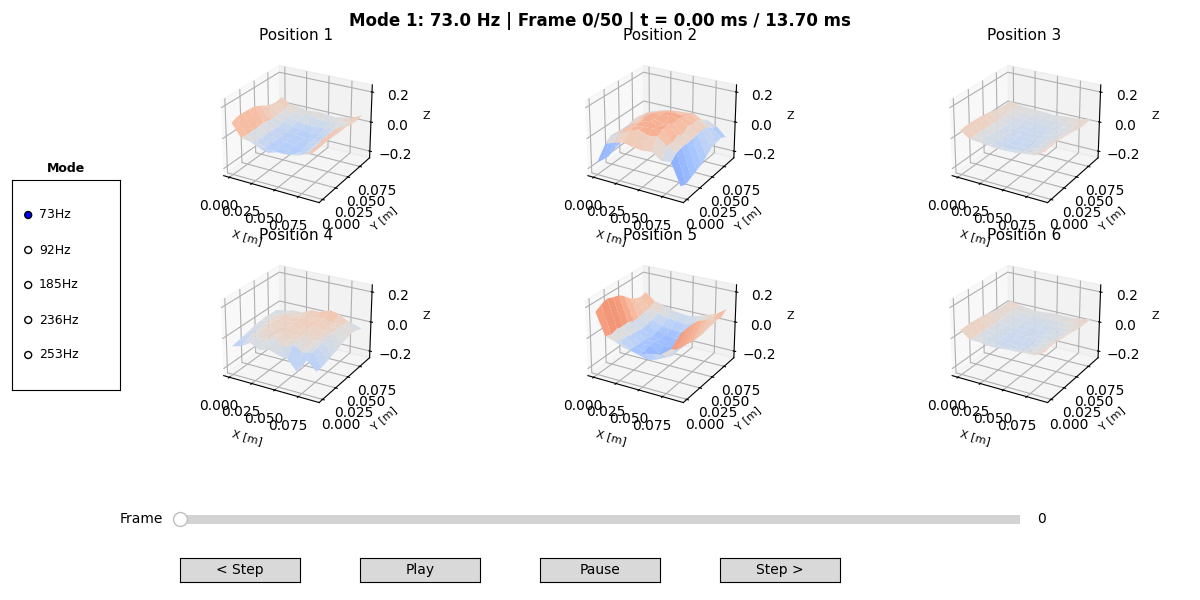

In [ ]:
# Animate surface modes across all positions
# Use the slider to move through time, radio buttons to select mode
# Play/Pause buttons control automatic animation, Step buttons for single frames
fig = animate_surface_modes(data, n_frames=50)
plt.show()

In [ ]:
for mode_idx in range(5):
    save_surface_animation(data, mode_idx, save_path=f'../results/modes/mode_{mode_idx+1}.gif')

Saving animation for Mode 1 (73.0 Hz) to ../results/modes/mode_0.gif...
Animation saved to ../results/modes/mode_0.gif
Saving animation for Mode 2 (92.3 Hz) to ../results/modes/mode_1.gif...
Animation saved to ../results/modes/mode_1.gif
Saving animation for Mode 3 (185.8 Hz) to ../results/modes/mode_2.gif...
Animation saved to ../results/modes/mode_2.gif
Saving animation for Mode 4 (236.2 Hz) to ../results/modes/mode_3.gif...
Animation saved to ../results/modes/mode_3.gif
Saving animation for Mode 5 (253.0 Hz) to ../results/modes/mode_4.gif...
Animation saved to ../results/modes/mode_4.gif


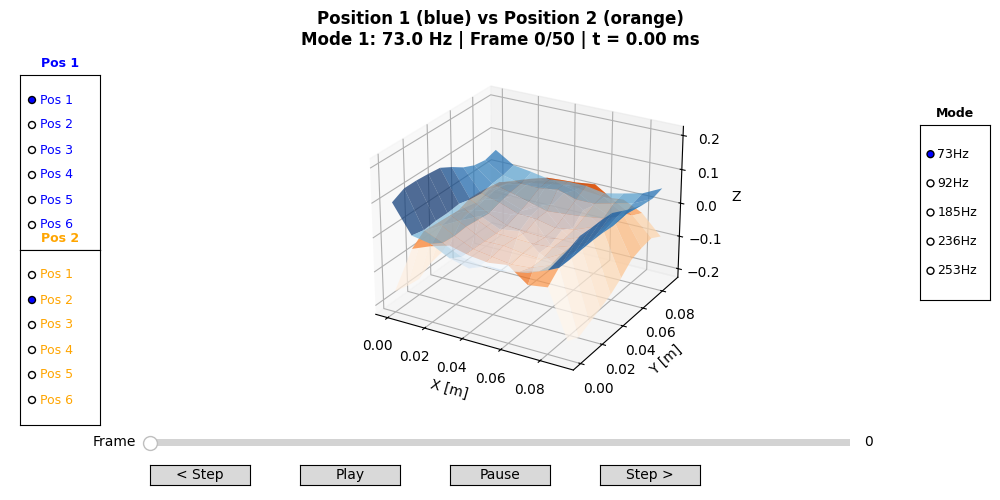

In [ ]:
fig = compare_positions(data)
plt.show()

# 6. PCA

In [ ]:
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
def compute_pca(data, max_n_components, x_key, y_key, fft_mode='both', return_x=False):
    """Compute PCA on FFT data from all experiments.

    Args:
        data: dict of experiment data
        max_n_components: max number of PCA components
        x_key: key for FFT values in data (e.g., 'synced_fft_vals')
        y_key: key for labels in data (e.g., 'position_xy' for tuples, 'position_idx' for int)
        fft_mode: 'both' (magnitude + angle), 'magnitude', or 'angle'

    Returns:
        X_pca: PCA-transformed features, shape (n_samples, n_components)
        y: labels list - can be tuples (position_xy) or ints (position_idx)
        var_exp: explained variance ratio per component
    """
    assert fft_mode in ['both', 'magnitude', 'angle']

    feature_vectors = []
    labels = []

    for name, d in data.items():
        fft_vals = d[x_key]  # shape: (n_lasers, n_modes, n_coords)
        features = fft_vals.flatten()

        # Convert complex FFT to real features based on mode
        if 'fft' in x_key and 'gradients' not in x_key:
            if fft_mode == 'magnitude':
                features = np.abs(fft_vals).flatten()
            elif fft_mode == 'angle':
                features = np.angle(fft_vals).flatten()
            else:  # 'both'
                mag = np.abs(fft_vals).flatten()
                ang = np.angle(fft_vals).flatten()
                features = np.concatenate([mag, ang])

        feature_vectors.append(features)
        labels.append(d[y_key])

    # Stack into matrix
    X = np.vstack(feature_vectors)
    # Keep labels as list to properly handle tuples (position_xy)
    y = labels

    # Normalize using StandardScaler
    scaler = StandardScaler()
    X_normalized = scaler.fit_transform(X)

    # PCA
    n_components = min(max_n_components, X.shape[0])
    pca = PCA(n_components=n_components, random_state=RANDOM_SEED)
    X_pca = pca.fit_transform(X_normalized)

    if return_x: return X_pca, y, pca.explained_variance_ratio_, X
    return X_pca, y, pca.explained_variance_ratio_

In [ ]:
def compute_pairwise_distance(X_pca, y):
    """Compute pairwise Euclidean distance matrix and duplicate position accuracy score.

    Args:
        X_pca: array of shape (n_samples, n_features)
        y: list of position labels - can be tuples or scalars

    Returns:
        distances: pairwise distance matrix of shape (n_samples, n_samples)
        duplicate_score: fraction of duplicate pairs where the closest sample has the same position
    """
    distances = cdist(X_pca, X_pca, metric='euclidean')

    # Normalize labels to tuples for consistent comparison
    y_list = [tuple(yi) if isinstance(yi, (list, np.ndarray)) else yi for yi in y]

    # Find duplicate positions (positions that appear more than once)
    from collections import Counter
    position_counts = Counter(y_list)
    duplicate_positions = {pos for pos, count in position_counts.items() if count > 1}

    if len(duplicate_positions) == 0:
        return distances, None  # No duplicates to compare

    # Create a mask for samples with duplicate positions
    duplicate_mask = np.array([yi in duplicate_positions for yi in y_list])
    duplicate_indices = np.where(duplicate_mask)[0]

    # Set diagonal to infinity to exclude self-comparisons
    distances_copy = distances.copy()
    np.fill_diagonal(distances_copy, np.inf)

    # For each duplicate sample, find the closest sample
    closest_indices = np.argmin(distances_copy[duplicate_indices], axis=1)

    # Check if the closest samples have the same position
    y_duplicates = [y_list[i] for i in duplicate_indices]
    y_closest = [y_list[i] for i in closest_indices]
    correct_matches = sum(yd == yc for yd, yc in zip(y_duplicates, y_closest))

    total_duplicate_pairs = len(duplicate_indices)
    duplicate_score = correct_matches / total_duplicate_pairs if total_duplicate_pairs > 0 else 0.0

    return distances, duplicate_score

In [ ]:
def get_position_color(pos, unique_positions):
    """Get a color for a position using a colormap.

    Args:
        pos: position label (can be tuple (x, y) or scalar)
        unique_positions: list of all unique positions for consistent color mapping

    Returns:
        color from colormap
    """
    idx = unique_positions.index(pos)
    n_total = len(unique_positions)
    # Use tab20 for up to 20 positions, otherwise use a continuous colormap
    if n_total <= 20:
        return plt.cm.tab20(idx / max(n_total - 1, 1))
    else:
        return plt.cm.viridis(idx / max(n_total - 1, 1))


def format_position_label(pos):
    """Format a position for display as a short label on scatter points.

    Args:
        pos: position label (can be tuple (x, y) or scalar)

    Returns:
        formatted string label
    """
    if isinstance(pos, (tuple, list)):
        return f"{pos[0]},{pos[1]}"
    return str(pos)


def format_position_legend(pos):
    """Format a position for display in legend.

    Args:
        pos: position label (can be tuple (x, y) or scalar)

    Returns:
        formatted string for legend
    """
    if isinstance(pos, (tuple, list)):
        return f"({pos[0]}, {pos[1]})"
    return f"Pos {pos}"


def plot_pca(X_pca, y, var_exp, title="", plot_2d=True, plot_3d=True):
    """Visualize PCA results in 2D and/or 3D with labeled scatter plots.

    Args:
        X_pca: PCA-transformed features, shape (n_samples, n_components)
        y: position labels, shape (n_samples,) - can be tuples (x, y) or scalars
        var_exp: explained variance ratio per component
        plot_2d: if True, create 2D plot (PC1 vs PC2)
        plot_3d: if True, create 3D plot (PC1 vs PC2 vs PC3)

    Returns:
        fig: matplotlib figure object
    """
    # Determine subplot layout
    n_plots = int(plot_2d) + int(plot_3d)
    if n_plots == 0:
        raise ValueError("At least one of plot_2d or plot_3d must be True")

    # Create figure
    fig = plt.figure(figsize=(4.5 * n_plots, 4))
    plot_idx = 1

    # Get unique positions (handle tuples properly)
    y_list = [tuple(yi) if isinstance(yi, (list, tuple, np.ndarray)) else yi for yi in y]
    unique_positions = sorted(set(y_list), key=lambda p: (p if isinstance(p, tuple) else (-1 if p is None else p,)))

    # Generate colors for each unique position
    colors = [get_position_color(pos, unique_positions) for pos in unique_positions]

    # 2D plot
    if plot_2d:
        ax = fig.add_subplot(1, n_plots, plot_idx)

        for pos, color in zip(unique_positions, colors):
            mask = np.array([yi == pos for yi in y_list])
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                      c=[color], s=200, alpha=0.7,
                      edgecolor='black', linewidth=1.5,
                      label=format_position_legend(pos))

            # Add position labels on top of each point
            for x_val, y_val in zip(X_pca[mask, 0], X_pca[mask, 1]):
                ax.text(x_val, y_val, format_position_label(pos),
                       ha='center', va='center',
                       fontsize=8, fontweight='bold', color='white')

        ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)', fontsize=11)
        ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)', fontsize=11)
        ax.set_title('PCA Projection (2D)', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        # Only show legend if few enough positions
        if len(unique_positions) <= 12:
            ax.legend(loc='best', fontsize=8)

        plot_idx += 1

    # 3D plot
    if plot_3d:
        from mpl_toolkits.mplot3d import proj3d

        ax = fig.add_subplot(1, n_plots, plot_idx, projection='3d')

        for pos, color in zip(unique_positions, colors):
            mask = np.array([yi == pos for yi in y_list])
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
                      c=[color], s=200, alpha=0.7,
                      edgecolor='black', linewidth=1.5,
                      label=format_position_legend(pos), depthshade=False)

        # Add all labels after scatter plots to ensure they render on top
        for i in range(len(y)):
            ax.text(X_pca[i, 0], X_pca[i, 1], X_pca[i, 2],
                   format_position_label(y_list[i]),
                   ha='center', va='center',
                   fontsize=8, fontweight='bold', color='white',
                   zorder=100)

        ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)', fontsize=10)
        ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)', fontsize=10)
        ax.set_zlabel(f'PC3 ({var_exp[2]*100:.1f}%)', fontsize=10)
        ax.set_title('PCA Projection (3D)', fontsize=13, fontweight='bold')

    if title: fig.suptitle(title)
    plt.tight_layout()
    return fig

In [ ]:
def plot_explained_variance(var_exp, title='PCA Explained Variance'):
    """Plot explained variance ratio per component as bar chart with cumulative line.

    Args:
        var_exp: array of explained variance ratios per component
        title: plot title

    Returns:
        fig: matplotlib figure object
    """
    n_components = len(var_exp)
    x = np.arange(1, n_components + 1)
    cumulative = np.cumsum(var_exp)

    fig, ax = plt.subplots(figsize=(8, 5))

    # Bar chart for individual variance
    bars = ax.bar(x, var_exp * 100, color='steelblue', alpha=0.7,
                  edgecolor='black', linewidth=1, label='Individual')

    # Add percentage labels on bars
    for bar, var in zip(bars, var_exp):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 1,
                f'{var*100:.1f}%', ha='center', va='bottom', fontsize=9)

    # Line plot for cumulative variance
    ax.plot(x, cumulative * 100, 'o-', color='darkorange', linewidth=2,
            markersize=8, label='Cumulative')

    # Add cumulative percentage labels
    for xi, cum in zip(x, cumulative):
        ax.text(xi + 0.1, cum * 100 + 2, f'{cum*100:.1f}%',
                ha='left', va='bottom', fontsize=9, color='darkorange')

    ax.set_xlabel('Principal Component', fontsize=11)
    ax.set_ylabel('Explained Variance (%)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'PC{i}' for i in x])
    ax.set_ylim(0, 110)
    ax.legend(loc='center right')
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    return fig

In [ ]:
list(d.keys())

['object',
 'x_position',
 'y_position',
 'position_xy',
 'position_idx',
 'duplicate_idx',
 'fs',
 'path',
 'shifts_raw',
 'time',
 'shifts',
 'fft_vals',
 'freqs',
 '_mode_freqs_idx',
 '_mode_freqs',
 '_mode_fft_vals',
 'mode_freqs',
 'mode_freqs_idx',
 'mode_fft_vals',
 'synced_fft_vals',
 'synced_mode_fft_vals',
 'mode_fft_gradients',
 'synced_fft_gradients',
 'synced_mode_fft_gradients']

In [ ]:
x_key='synced_fft_vals'

X_pca, y, var_exp = compute_pca(
    data, max_n_components=8,
    x_key=x_key, y_key='position_xy', fft_mode='magnitude'
    )
dist_matrix, duplicate_score = compute_pairwise_distance(X_pca, y)

var_exp

array([0.24210259, 0.06840831, 0.05998827, 0.03749364, 0.02918933,
       0.02321341, 0.022279  , 0.02103994])

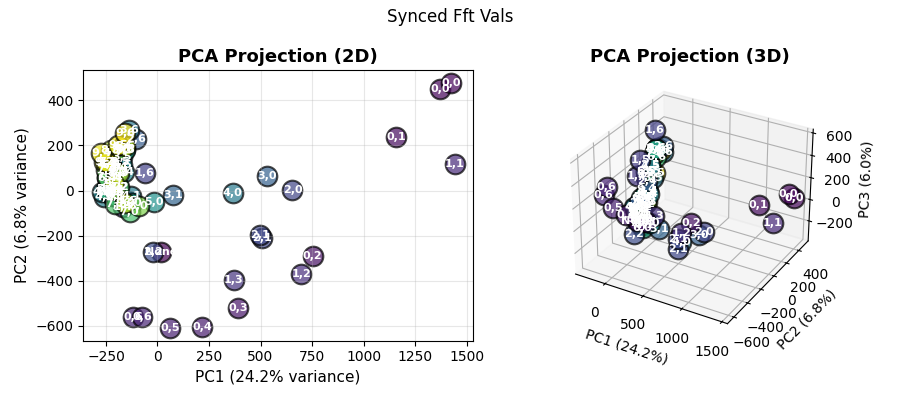

In [ ]:
# Plot both 2D and 3D
fig = plot_pca(X_pca, y, var_exp, title=x_key.replace('_', ' ').title())
plt.show()

In [ ]:
plt.close(fig)

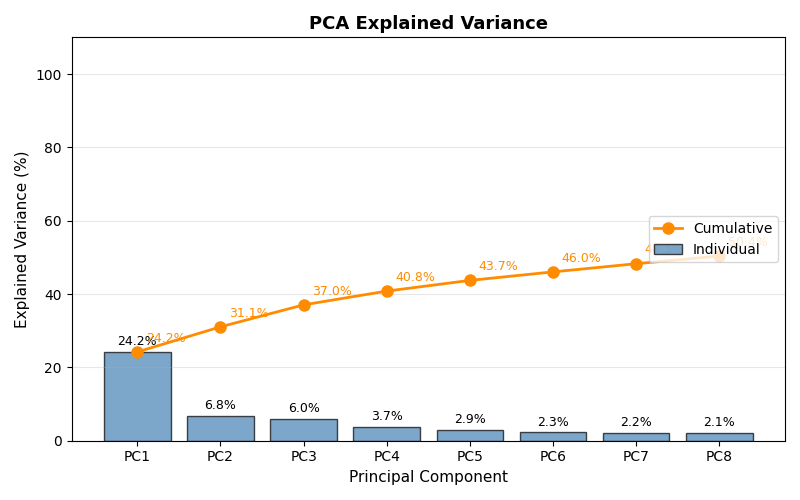

In [ ]:
fig = plot_explained_variance(var_exp)
plt.show()

In [ ]:
plt.close(fig)

In [ ]:
list(d.keys())

['object',
 'x_position',
 'y_position',
 'position_xy',
 'position_idx',
 'duplicate_idx',
 'fs',
 'path',
 'shifts_raw',
 'time',
 'shifts',
 'fft_vals',
 'freqs',
 '_mode_freqs_idx',
 '_mode_freqs',
 '_mode_fft_vals',
 'mode_freqs',
 'mode_freqs_idx',
 'mode_fft_vals',
 'synced_fft_vals',
 'synced_mode_fft_vals',
 'mode_fft_gradients',
 'synced_fft_gradients',
 'synced_mode_fft_gradients']

In [ ]:
x_keys = ['shifts_raw', 'shifts', 'fft_vals', 'synced_fft_vals', 'synced_mode_fft_vals', 'synced_mode_fft_gradients']
labels = ['1. Raw Shifts', '2. Cleaned Shifts', '3. FFT Magnitude', '4. Synced FFT Magnitude', '5. Mode Synced FFT Magnitude', '6. Mode Synced Gradient']

In [ ]:
max_n_components = 8
fig, ax = plt.subplots(figsize=(10, 5))
fi2, ax2 = plt.subplots(figsize=(10, 5))

for x_key, _label in zip(x_keys, labels):
        X_pca, y, var_exp, X = compute_pca(data, max_n_components=max_n_components, x_key=x_key, y_key='position_xy', fft_mode='magnitude', return_x=True)

        n_dims = X.shape[1] # todo: shouldn't n_dims be different for mode vs all frequencies?
        label = _label + f' ({n_dims} dims)'
        print(label)

        n_components = len(var_exp)
        x = np.arange(1, n_components + 1)
        cumulative = np.cumsum(var_exp)

        # plot cumulative variance
        ax.plot(x, cumulative * 100, 'o-',linewidth=2, markersize=8, label=label)
        for xi, cum in zip(x, cumulative):
                ax.text(xi + 0.1, cum * 100 + 2, f'{cum*100:.1f}%', ha='left', va='bottom', fontsize=9)

        # plot duplicate scores
        duplicate_scores = np.array([compute_pairwise_distance(X_pca[:, :pca_dim+1], y)[1] for pca_dim in range(max_n_components)])
        ax2.plot(x, duplicate_scores*100, 'o-',linewidth=2, markersize=8, label=label)
        for xi, score in zip(x, duplicate_scores):
                ax2.text(xi + 0.1, score * 100 + 2, f'{score*100:.1f}%', ha='left', va='bottom', fontsize=9)

        # plot 2d/3d PCA
        fig3 = plot_pca(X_pca, y, var_exp, title=label)
        plt.show()
        plt.close(fig3)

ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Explained Variance (%)', fontsize=11)
ax.set_title('Cumulative Explained Variance', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'PC{i}' for i in x])
ax.set_ylim(0, 110)
ax.legend(loc='center right')
ax.grid(True, alpha=0.3, axis='y')


ax2.set_xlabel('Principal Component', fontsize=11)
ax2.set_ylabel('Duplicate Score (%)', fontsize=11)
ax2.set_title('Duplicate Score', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f'PC{i}' for i in x])
ax2.set_ylim(-10, 110)
ax2.legend(loc='center right')
ax2.grid(True, alpha=0.3, axis='y')

plt.show()
plt.close(fig)
plt.close(fi2)

In [ ]:
import pandas as pd

In [ ]:
results = []


x_keys = ['shifts_raw', 'shifts', 'fft_vals', 'synced_fft_vals', 'mode_fft_vals', 'synced_mode_fft_vals', 'synced_mode_fft_gradients', 'synced_fft_gradients']

max_n_components = 8
for x_key in x_keys:
    X_pca, y, var_exp, X = compute_pca(data, max_n_components=max_n_components, x_key=x_key, y_key='position_xy', fft_mode='magnitude', return_x=True)

    n_components = len(var_exp)
    x = np.arange(1, n_components + 1)
    cumulative_var_exp = np.cumsum(var_exp)

    n_dims = X.shape[1]
    synced = 'synced' in x_key
    n_modes = (d[x_key].shape[0] if 'gradients' in x_key else d[x_key].shape[1]) if 'mode' in x_key else -1
    signal = x_key.replace('synced_', '').replace('mode_', '').replace('fft_gradients', 'gradients')

    for pca_dim in range(max_n_components):
        _, duplicate_score = compute_pairwise_distance(X_pca[:, :pca_dim+1], y)
        results.append({
            'signal': signal,
            'pca_dim': pca_dim,
            'n_modes': n_modes,
            'synced': synced,
            'n_dims': n_dims,
            'cum_var_exp': cumulative_var_exp[pca_dim],
            'duplicate_score': duplicate_score,
        })

In [ ]:
df = pd.DataFrame(results)
df.head(50)

,signal,pca_dim,n_modes,synced,n_dims,cum_var_exp,duplicate_score
0,shifts_raw,0,-1,False,6000000,0.194276,0.00
1,shifts_raw,1,-1,False,6000000,0.353425,0.00
2,shifts_raw,2,-1,False,6000000,0.499477,0.00
3,shifts_raw,3,-1,False,6000000,0.639295,0.00
4,shifts_raw,4,-1,False,6000000,0.769780,0.00
5,shifts_raw,5,-1,False,6000000,0.890420,0.25
6,shifts_raw,6,-1,False,6000000,1.000000,0.00
7,shifts_raw,7,-1,False,6000000,1.000000,0.00
8,shifts,0,-1,False,6000000,0.187303,0.00
9,shifts,1,-1,False,6000000,0.357147,0.00


# 7. Correlation

The complex FFT value at one laser point, at one mode frequency, in one direction (x or y)

The phase synchronization (sync_phases) aligns all phases relative to laser 0's x-component, so phase differences between positions are meaningful.

The normalized complex inner product: corr(pos_i, pos_j) = ⟨v_i, v_j⟩ / (‖v_i‖ · ‖v_j‖). This measures how similar the entire vibration signature is between two positions—considering all 100 laser points, all 5 modes, both x/y directions, and both amplitude and phase.

1. Magnitude ≈ 1.0: The two positions have very similar vibration patterns
2. Magnitude ≈ 0: The patterns are uncorrelated (orthogonal in the 1000-D space)
3. Phase ≈ 0: The patterns are in-phase (peaks align)
4. Phase ≈ ±π: The patterns are anti-correlated (one's peaks are the other's troughs)

In [ ]:
def compute_complex_correlation(data, fft_key='synced_mode_fft_vals'):
    """Compute pairwise complex correlation between positions.

    Args:
        data: dict of experiment data
        fft_key: key for FFT values to use (default: 'synced_mode_fft_vals')

    Returns:
        corr_matrix: complex correlation matrix of shape (n_positions, n_positions)
        positions: list of position indices
    """
    positions = sorted(set(d['position'] for d in data.values() if d['duplicate_idx'] == 1))
    n_pos = len(positions)

    # Extract flattened complex vectors for each position
    vectors = {}
    for name, d in data.items():
        if d['duplicate_idx'] != 1:
            continue
        # Flatten: (100, 5, 2) -> (1000,) complex vector
        vectors[d['position']] = d[fft_key].flatten()

    # Compute correlation matrix
    corr_matrix = np.zeros((n_pos, n_pos), dtype=complex)
    for i, pos_i in enumerate(positions):
        for j, pos_j in enumerate(positions):
            v_i = vectors[pos_i]
            v_j = vectors[pos_j]
            # Normalized complex correlation (inner product / norms)
            corr = np.vdot(v_i, v_j) / (np.linalg.norm(v_i) * np.linalg.norm(v_j))
            corr_matrix[i, j] = corr

    return corr_matrix, positions


def compute_complex_correlation_per_mode(data, fft_key='synced_mode_fft_vals'):
    """Compute pairwise complex correlation between positions for each mode frequency separately.

    Args:
        data: dict of experiment data
        fft_key: key for FFT values to use (default: 'synced_mode_fft_vals')

    Returns:
        corr_matrices: dict mapping mode_idx -> complex correlation matrix of shape (n_positions, n_positions)
        positions: list of position indices
        mode_freqs: array of mode frequencies
    """
    positions = sorted(set(d['position'] for d in data.values() if d['duplicate_idx'] == 1))
    n_pos = len(positions)

    # Get mode frequencies from first valid entry
    d0 = next(d for d in data.values() if d['duplicate_idx'] == 1)
    mode_freqs = d0['mode_freqs']
    n_modes = len(mode_freqs)

    # Determine data shape based on key type
    is_gradients = 'gradients' in fft_key

    # Extract per-mode complex vectors for each position
    # synced_mode_fft_vals shape: (100, 5, 2) -> 100 lasers, 5 modes, 2 directions (x,y)
    # synced_mode_fft_gradients shape: (5, 2, 10, 10) -> 5 modes, 2 gradient dirs, 10x10 grid
    vectors_per_mode = {mode_idx: {} for mode_idx in range(n_modes)}

    for name, d in data.items():
        if d['duplicate_idx'] != 1:
            continue
        pos = d['position']
        fft_data = d[fft_key]

        for mode_idx in range(n_modes):
            if is_gradients:
                # gradients shape: (n_modes, 2, 10, 10) -> extract mode_idx and flatten
                vec = fft_data[mode_idx].flatten()  # (2, 10, 10) -> (200,)
            else:
                # fft_vals shape: (100, n_modes, 2) -> extract mode_idx and flatten
                vec = fft_data[:, mode_idx, :].flatten()  # (100, 2) -> (200,)
            vectors_per_mode[mode_idx][pos] = vec

    # Compute correlation matrix for each mode
    corr_matrices = {}
    for mode_idx in range(n_modes):
        corr_matrix = np.zeros((n_pos, n_pos), dtype=complex)
        vectors = vectors_per_mode[mode_idx]

        for i, pos_i in enumerate(positions):
            for j, pos_j in enumerate(positions):
                v_i = vectors[pos_i]
                v_j = vectors[pos_j]
                # Normalized complex correlation (inner product / norms)
                corr = np.vdot(v_i, v_j) / (np.linalg.norm(v_i) * np.linalg.norm(v_j))
                corr_matrix[i, j] = corr

        corr_matrices[mode_idx] = corr_matrix

    return corr_matrices, positions, mode_freqs


In [ ]:
from matplotlib.patheffects import withStroke

def plot_correlation_matrix(corr_matrix, positions, title="Complex Correlation Between Positions"):
    """Plot magnitude and phase of complex correlation as heatmaps.

    Args:
        corr_matrix: complex correlation matrix of shape (n_positions, n_positions)
        positions: list of position indices
        title: figure title

    Returns:
        fig: matplotlib figure
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Magnitude heatmap
    im1 = axes[0].imshow(np.abs(corr_matrix), cmap='viridis', vmin=0, vmax=1)
    axes[0].set_title('Correlation Magnitude')
    axes[0].set_xticks(range(len(positions)))
    axes[0].set_yticks(range(len(positions)))
    axes[0].set_xticklabels([f'Pos {p}' for p in positions])
    axes[0].set_yticklabels([f'Pos {p}' for p in positions])
    plt.colorbar(im1, ax=axes[0])

    # Add magnitude values as text
    for i in range(len(positions)):
        for j in range(len(positions)):
            val = np.abs(corr_matrix[i, j])
            axes[0].text(j, i, f'{val:.2f}', ha='center', va='center',
                        color='white' if val < 0.5 else 'black', fontsize=9)

    # Phase heatmap
    phase_vals = np.angle(corr_matrix)
    im2 = axes[1].imshow(phase_vals, cmap='twilight', vmin=-np.pi, vmax=np.pi)
    axes[1].set_title('Correlation Phase')
    axes[1].set_xticks(range(len(positions)))
    axes[1].set_yticks(range(len(positions)))
    axes[1].set_xticklabels([f'Pos {p}' for p in positions])
    axes[1].set_yticklabels([f'Pos {p}' for p in positions])
    plt.colorbar(im2, ax=axes[1], label='Phase (rad)')

    # Add phase values as text (use white text with black outline for visibility)
    for i in range(len(positions)):
        for j in range(len(positions)):
            val = phase_vals[i, j]
            # Use white text with black stroke for visibility on twilight colormap
            txt = axes[1].text(j, i, f'{val:.2f}', ha='center', va='center',
                              fontsize=9, fontweight='bold', color='white')
            txt.set_path_effects([withStroke(linewidth=2, foreground='black')])

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig


def plot_correlation_matrices_per_mode(corr_matrices, positions, mode_freqs, title_prefix="Complex Correlation"):
    """Plot magnitude and phase heatmaps for each mode frequency separately.

    Args:
        corr_matrices: dict mapping mode_idx -> complex correlation matrix
        positions: list of position indices
        mode_freqs: array of mode frequencies
        title_prefix: prefix for figure titles

    Returns:
        figs: list of matplotlib figures (one per mode)
    """
    figs = []
    n_modes = len(corr_matrices)

    for mode_idx in range(n_modes):
        corr_matrix = corr_matrices[mode_idx]
        freq = mode_freqs[mode_idx]
        title = f"{title_prefix} - Mode {mode_idx + 1} ({freq:.1f} Hz)"
        fig = plot_correlation_matrix(corr_matrix, positions, title=title)
        figs.append(fig)

    return figs


In [ ]:
# Compute and visualize complex correlation between positions (aggregated across all modes)
corr_matrix, positions = compute_complex_correlation(data, fft_key='synced_mode_fft_vals')

print("Complex Correlation Matrix - All Modes Combined (magnitude):")
print(np.abs(corr_matrix).round(3))
print("\nDiagonal should be 1.0 (self-correlation)")

fig = plot_correlation_matrix(corr_matrix, positions, title="Complex Correlation - All Modes Combined")
plt.show()
plt.close(fig)

# Compute and visualize complex correlation for EACH mode frequency separately
print("\n" + "="*60)
print("Per-Mode Correlation Analysis")
print("="*60)

corr_matrices_per_mode, positions, mode_freqs = compute_complex_correlation_per_mode(data, fft_key='synced_mode_fft_vals')

for mode_idx, corr_matrix in corr_matrices_per_mode.items():
    freq = mode_freqs[mode_idx]
    print(f"\nMode {mode_idx + 1} ({freq:.1f} Hz) - Correlation Magnitude:")
    print(np.abs(corr_matrix).round(3))

# Plot each mode's correlation separately
figs = plot_correlation_matrices_per_mode(corr_matrices_per_mode, positions, mode_freqs, title_prefix="Complex Correlation (FFT Values)")
for fig in figs:
    plt.show()
    plt.close(fig)

In [ ]:
# Compute and visualize complex correlation between positions using gradients (aggregated)
corr_matrix_grad, positions_grad = compute_complex_correlation(data, fft_key='synced_mode_fft_gradients')

print("Complex Correlation Matrix - Gradients, All Modes Combined (magnitude):")
print(np.abs(corr_matrix_grad).round(3))

fig = plot_correlation_matrix(corr_matrix_grad, positions_grad, title="Complex Correlation - Gradients, All Modes Combined")
plt.show()
plt.close(fig)

# Compute and visualize complex correlation for EACH mode frequency separately (gradients)
print("\n" + "="*60)
print("Per-Mode Correlation Analysis (Gradients)")
print("="*60)

corr_matrices_grad_per_mode, positions_grad, mode_freqs = compute_complex_correlation_per_mode(data, fft_key='synced_mode_fft_gradients')

for mode_idx, corr_matrix in corr_matrices_grad_per_mode.items():
    freq = mode_freqs[mode_idx]
    print(f"\nMode {mode_idx + 1} ({freq:.1f} Hz) - Gradient Correlation Magnitude:")
    print(np.abs(corr_matrix).round(3))

# Plot each mode's correlation separately
figs = plot_correlation_matrices_per_mode(corr_matrices_grad_per_mode, positions_grad, mode_freqs, title_prefix="Complex Correlation - Gradients")
for fig in figs:
    plt.show()
    plt.close(fig)